In [1]:
import pandas as pd
import numpy as np
import os, chardet, glob
import matplotlib.pyplot as plt
import seaborn

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras import Sequential, optimizers, losses, layers

%matplotlib inline

Reading an Excel file named 'Overview.xlsx' located in the '/content/drive/MyDrive/Measurement_Data/' directory and assigning the data to the DataFrame 'df_overview'.
Dropping the columns 'Unnamed: 13' and 'Note' from the DataFrame using the drop() function.
Removing any rows with missing values (NaN) from the DataFrame using the dropna() function. We are also renaming the column 'Unnamed: 8' to 'SoC difference' using the rename() function. Finally, we display the first few rows of the updated DataFrame using the head() function.

In [2]:
df_overview = pd.read_excel('C:/Users/manis/Downloads/EVproject/archive/Overview.xlsx')
df_overview = df_overview.drop(['Unnamed: 13','Note'], axis=1)
df_overview = df_overview.dropna()
df_overview.rename(columns = {'Unnamed: 8':'SoC difference'}, inplace = True)
df_overview.head()

,Trip,Date,Route/Area,Weather,Battery Temperature (Start) [°C],Battery Temperature (End),SOC,displayed_SOC,SoC difference,Ambient Temperature (Start) [°C],Target Cabin Temperature,Distance [km],Duration [min],Fan
0,TripA01,2019-06-25_13-21-14,Munich East,sunny,21.0,22.0,0.863,0.803,0.060,25.5,23.0,7.427690,16.820000,"Automatic, Level 1"
1,TripA02,2019-06-25_14-05-31,Munich East,sunny,23.0,26.0,0.803,0.673,0.130,32.0,23.0,23.509709,23.550000,"Automatic, Level 1"
2,TripA03,2019-06-28_10-02-15,Munich East,sunny,24.0,25.0,0.835,0.751,0.084,21.5,27.0,12.820846,11.180000,"Automatic, Level 1"
3,TripA04,2019-06-28_10-13-30,Munich East,sunny,25.0,27.0,0.751,0.667,0.084,24.0,22.0,10.727491,6.870000,"Automatic, Level 1"
4,TripA05,2019-06-28_10-20-26,Munich East,sunny,27.0,27.0,0.667,0.602,0.065,24.5,24.0,12.393223,22.776667,"Automatic, Level 1"



Reading multiple CSV datasets and combining them into a single file.
The function then concatenates each DataFrame (df_trip) with the df_master DataFrame. Finally, the combined DataFrame is saved to a new CSV file named 'AllTripsNeeded.csv' in the same directory. The function returns the df_master DataFrame. Only merging the TripB csvs

In [3]:
def combine_csvs():
    ''' Combine all csv datasets into a single file'''
    df_master = pd.DataFrame()
    for filename in glob.glob('/C:/Users/manis/Downloads/EVproject/archive/*.csv'):
        df_trip = pd.read_csv(
            filename,
            sep=';',
            encoding=chardet.detect(open(filename, 'rb').read())['encoding']
        )
        df_master = pd.concat([df_master, df_trip])
        df_master.to_csv('/C:/Users/manis/Downloads/EVproject/archive/AllTrips.csv', index=False)
    return df_master

Plotting a grid of variables from a DataFrame as subplots.
The function iterates over the columns of the DataFrame and plots each column as a line plot. The x-axis values are calculated as an array ranging from 0 to the number of rows in the DataFrame multiplied by 0.1. The y-axis values are taken from the corresponding column of the DataFrame. Each subplot is labeled with the column name as the y-axis label. Grid lines are displayed, and the x-axis label is set to the first measurement column.

In [4]:
def plot_dataframe_subplots(df, nrows, ncols, figsize=(30, 24)):
    """Plot a nrows x ncols grid of the df variables"""
    measurements = list(df.columns)
    plt.figure(figsize=figsize)
    for idx, key in enumerate(measurements):
        plt.subplot(nrows, ncols, idx+1)
        plt.plot(np.array(range(df.shape[0]))*0.1, df[key])
        plt.ylabel(key)
        plt.grid(True)
        plt.xlabel(measurements[0])
        plt.show

In [7]:
# Load in the dataset
if os.path.exists('/C:/Users/manis/Downloads/EVproject/archive/AllTrips.csv'):
    df_master = pd.read_csv('/C:/Users/manis/Downloads/EVproject/archive/AllTrips.csv')
else: df_master = combine_csvs()

In [8]:
df_master.head()

""


In [9]:
# Remove last 2 columns since they are Nan
df_master = df_master.iloc[: , :-2]
print(list(df_master.columns.values))

[]


In [11]:
# Plot results of all trips
plot_dataframe_subplots(df_master, nrows=12, ncols=4, figsize=(30, 48))

<Figure size 3000x4800 with 0 Axes>

Analyzing battery State of Charge (SoC) degradation over vehicle exploitation and plotting the data.
first create a new DataFrame (df_soc) containing the 'SoC [%]' and 'displayed SoC [%]' columns from the df_master DataFrame, after dropping any rows with missing values.

Two lines are plotted on the graph: one representing the real SoC values (df_soc['SoC [%]']) in white color, and the other representing the normalized SoC values (df_soc['displayed SoC [%]']) in yellow color.

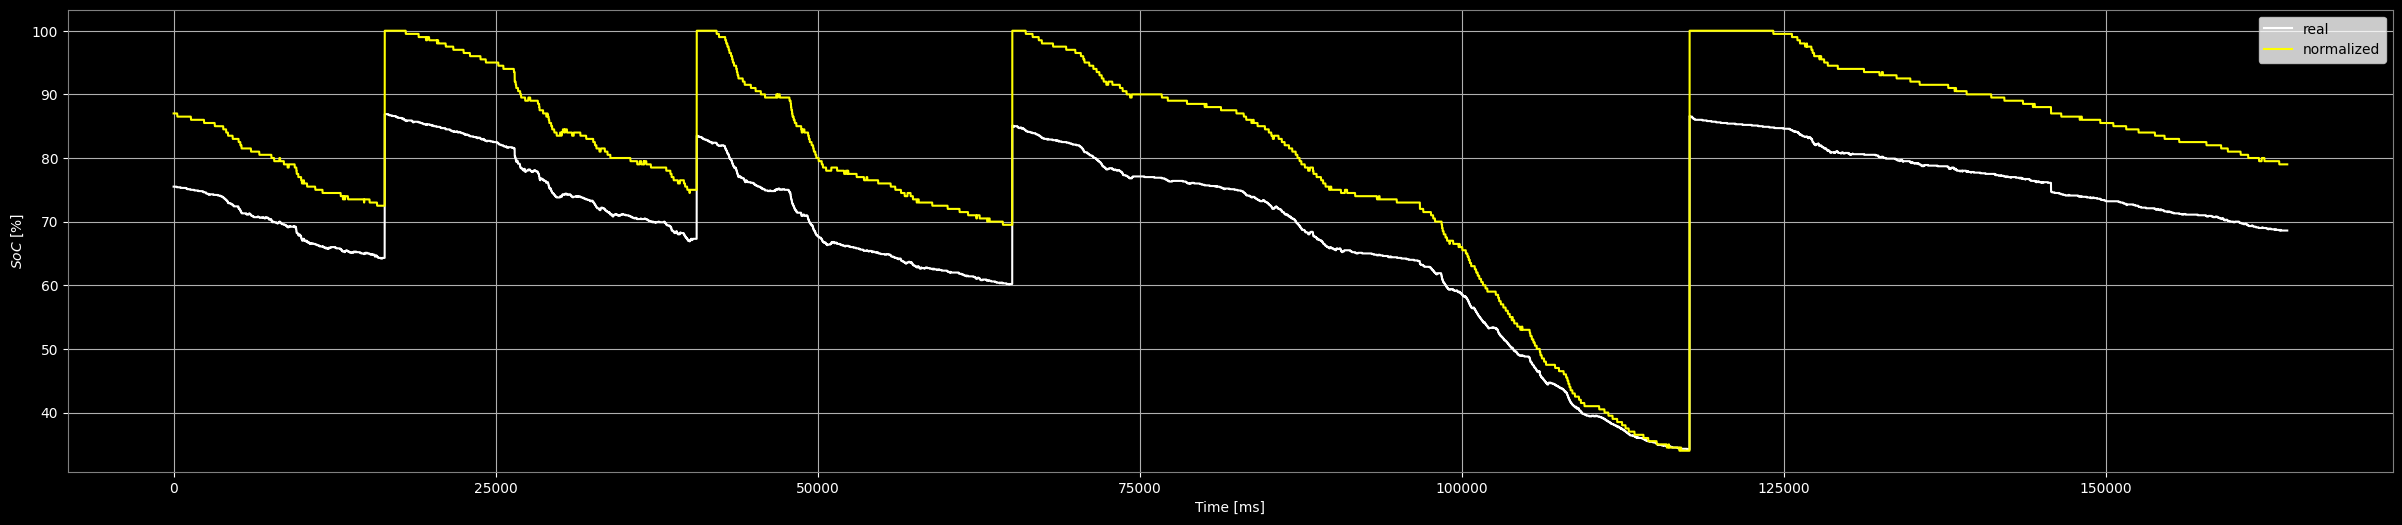

In [ ]:
df_soc = df_master[['SoC [%]', 'displayed SoC [%]']].dropna()
# Let us look at battery SoC degradation over vehicle exploitation
plt.figure(figsize=(30, 6), facecolor='black')
ax = plt.axes()
ax.set_facecolor("black")
ax.spines['bottom'].set_color('gray')
ax.spines['top'].set_color('gray')
ax.spines['right'].set_color('gray')
ax.spines['left'].set_color('gray')
ax.tick_params(colors='white', which='both')
plt.grid(True)

plt.plot(df_soc['SoC [%]'], color="white")
plt.plot(df_soc['displayed SoC [%]'], color="yellow")
plt.xlabel('Time [ms]', color='white')
plt.ylabel('$SoC$ [%]', color='white')
plt.legend(['real','normalized'])
plt.show()

<Axes: >

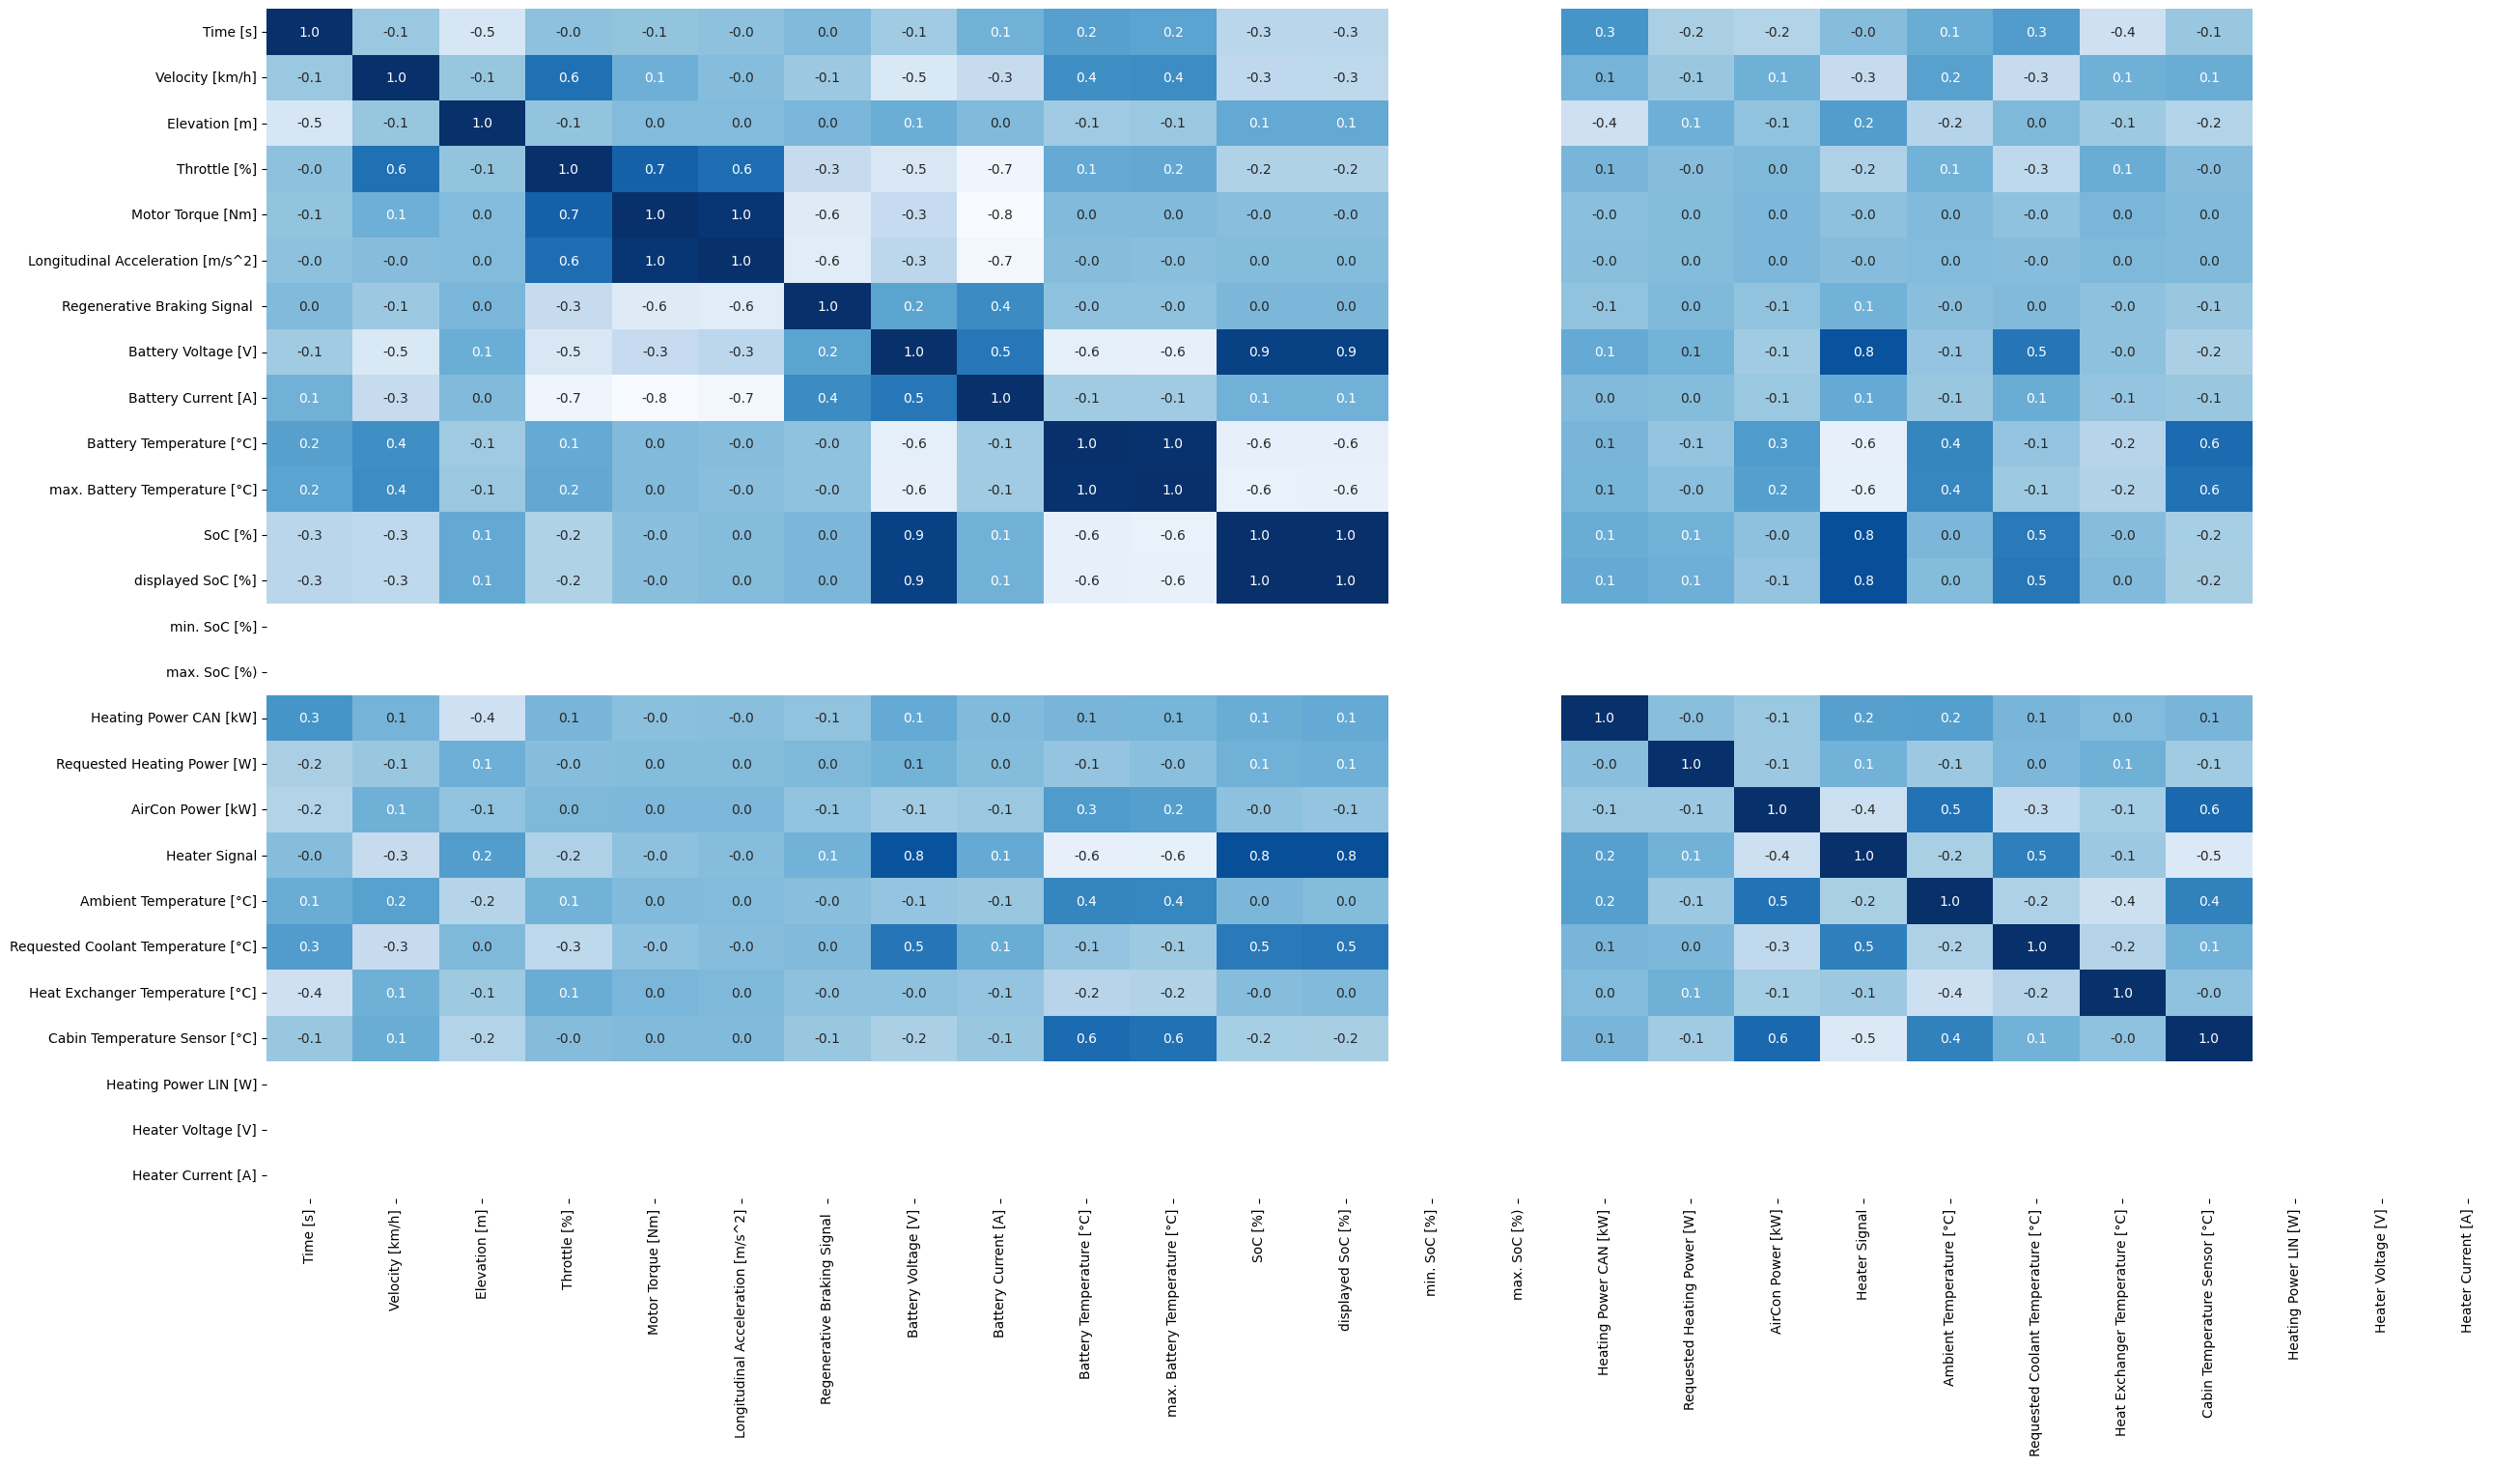

In [ ]:
# Correlation between features
plt.figure(figsize=(30, 16))
seaborn.heatmap(df_master.corr(),annot=True, cbar=False, cmap='Blues', fmt='.1f')

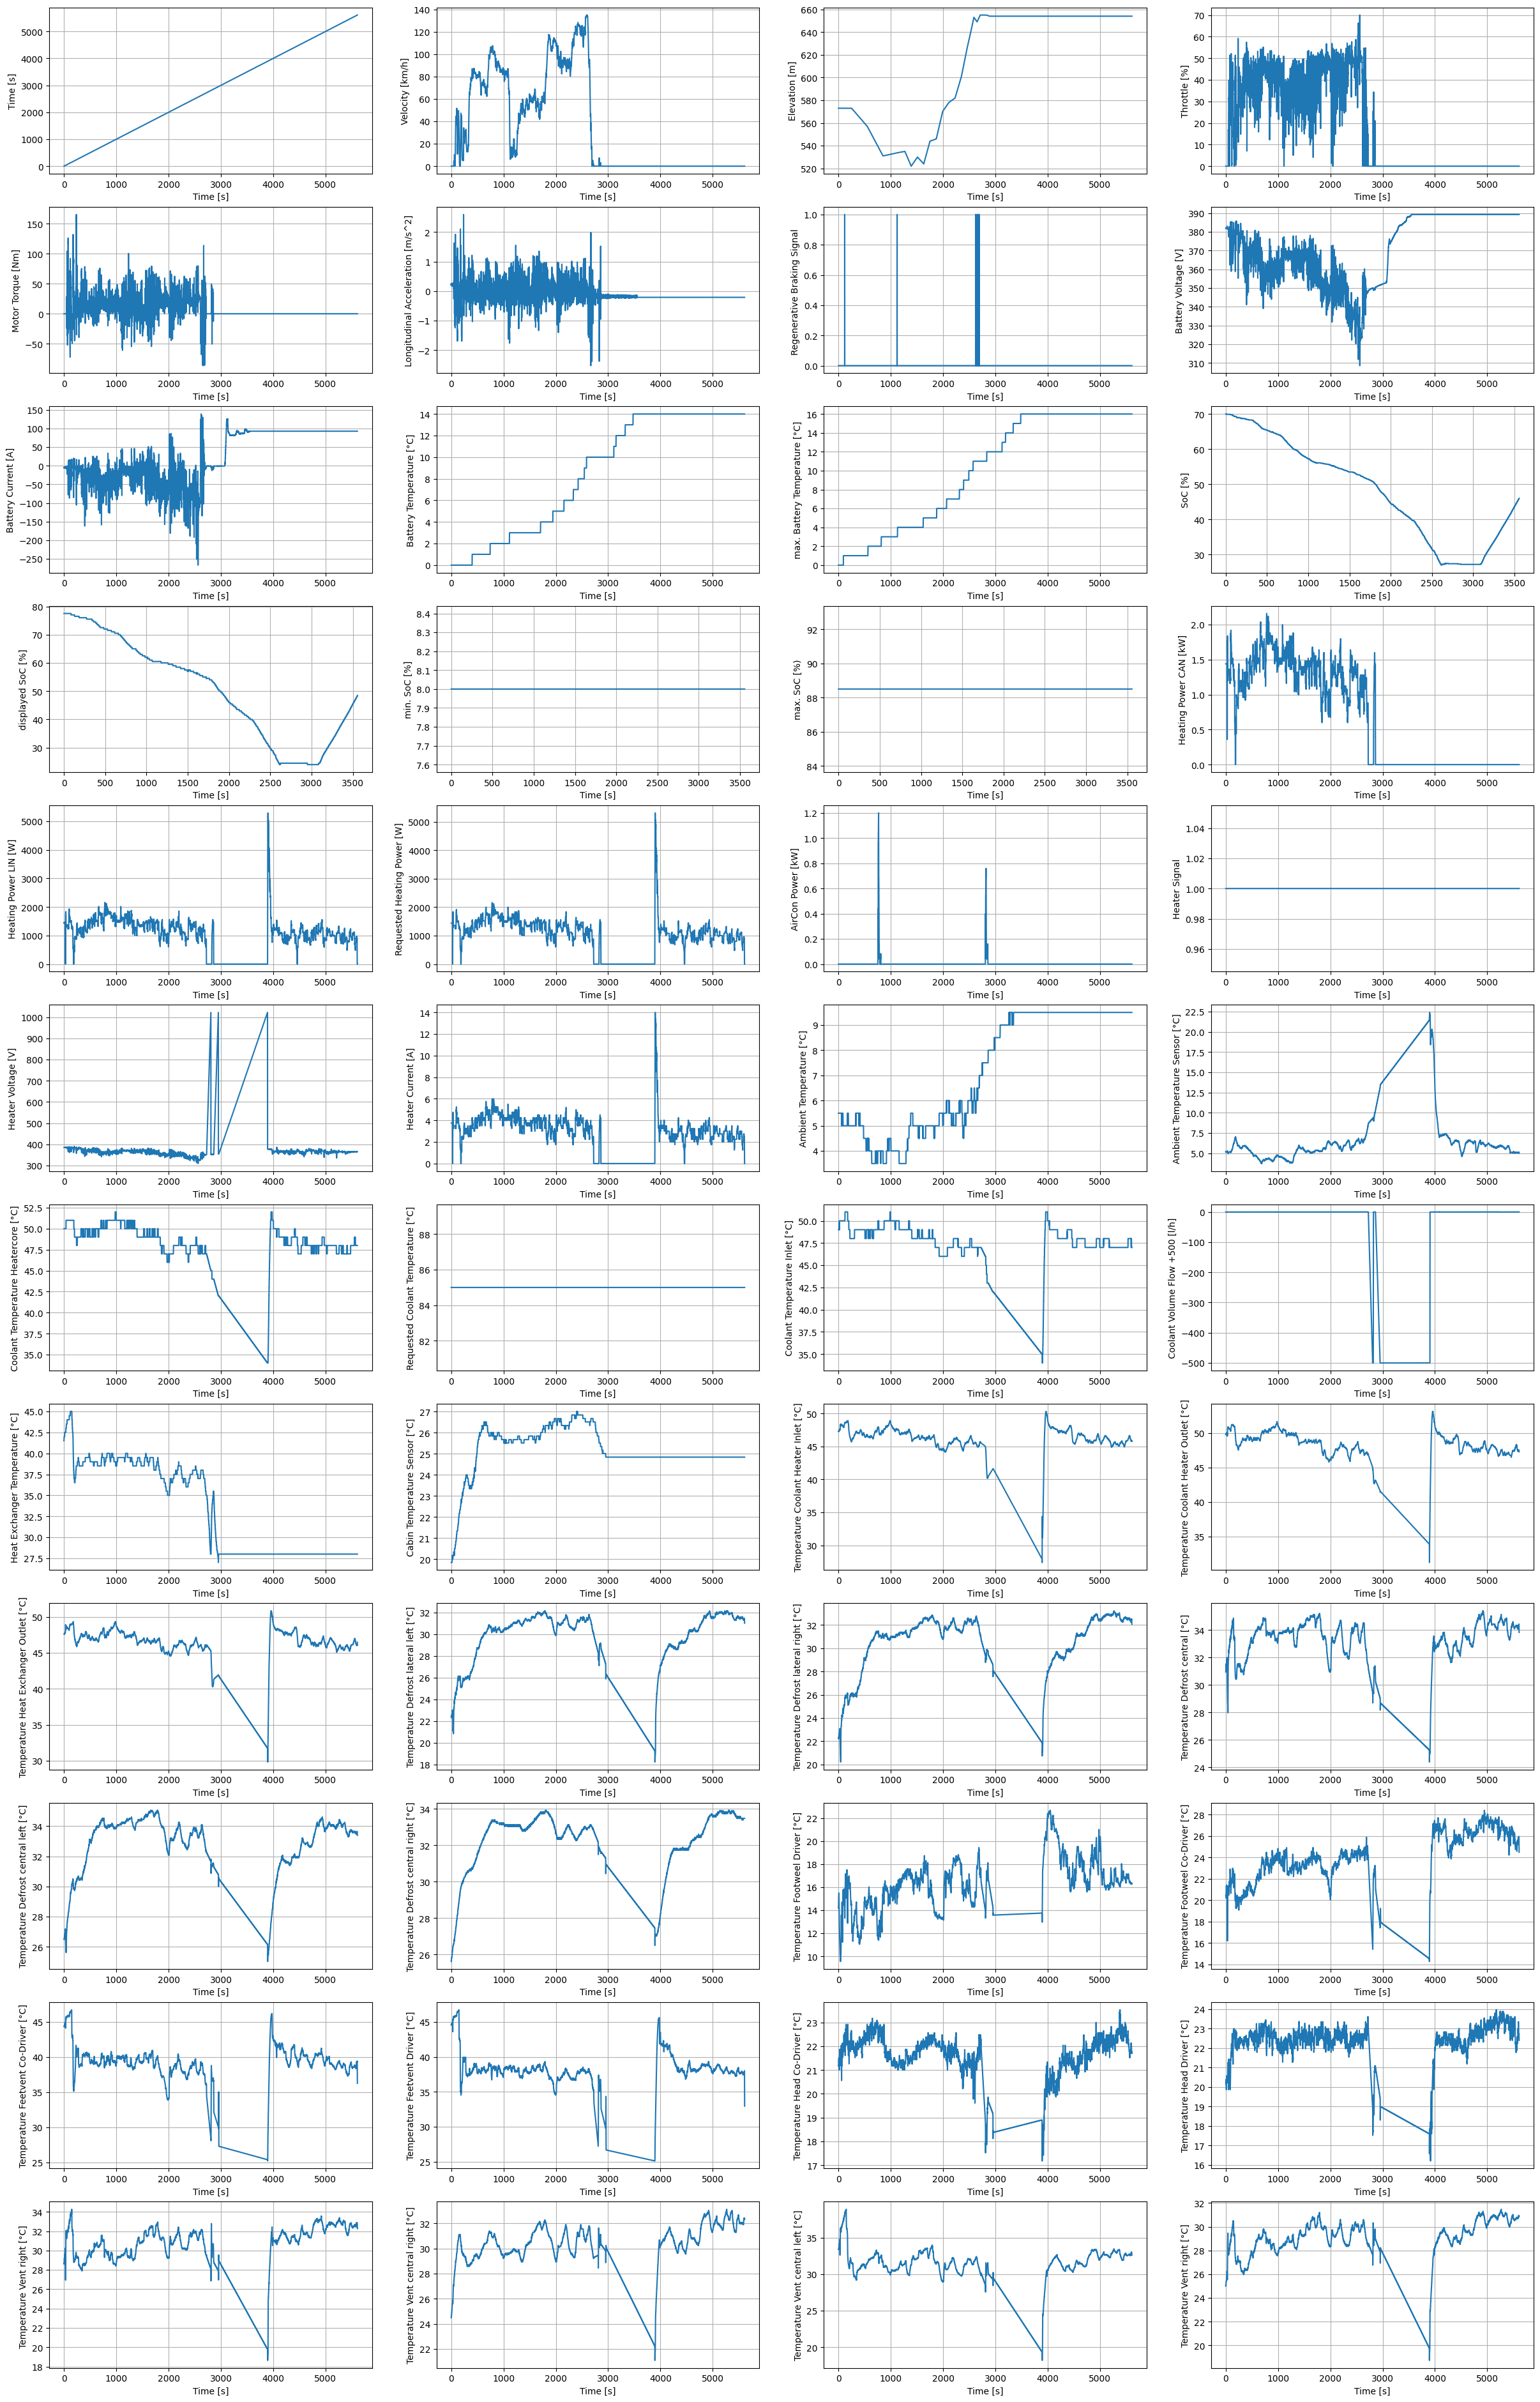

In [ ]:
#Single Trip
# Bring in a single trip as dataframe
#analyze the data from the 'TripB09.csv' file in a grid of subplots.
df_trip = pd.read_csv(
    '/content/drive/MyDrive/Measurement_Data/TripB09.csv',
    sep=';',
    encoding=chardet.detect(open(f'/content/drive/MyDrive/Measurement_Data/TripA08.csv', 'rb').read())['encoding']
)
# Plot results of a single trips
plot_dataframe_subplots(df_trip, nrows=12, ncols=4, figsize=(30, 48))

<Axes: >

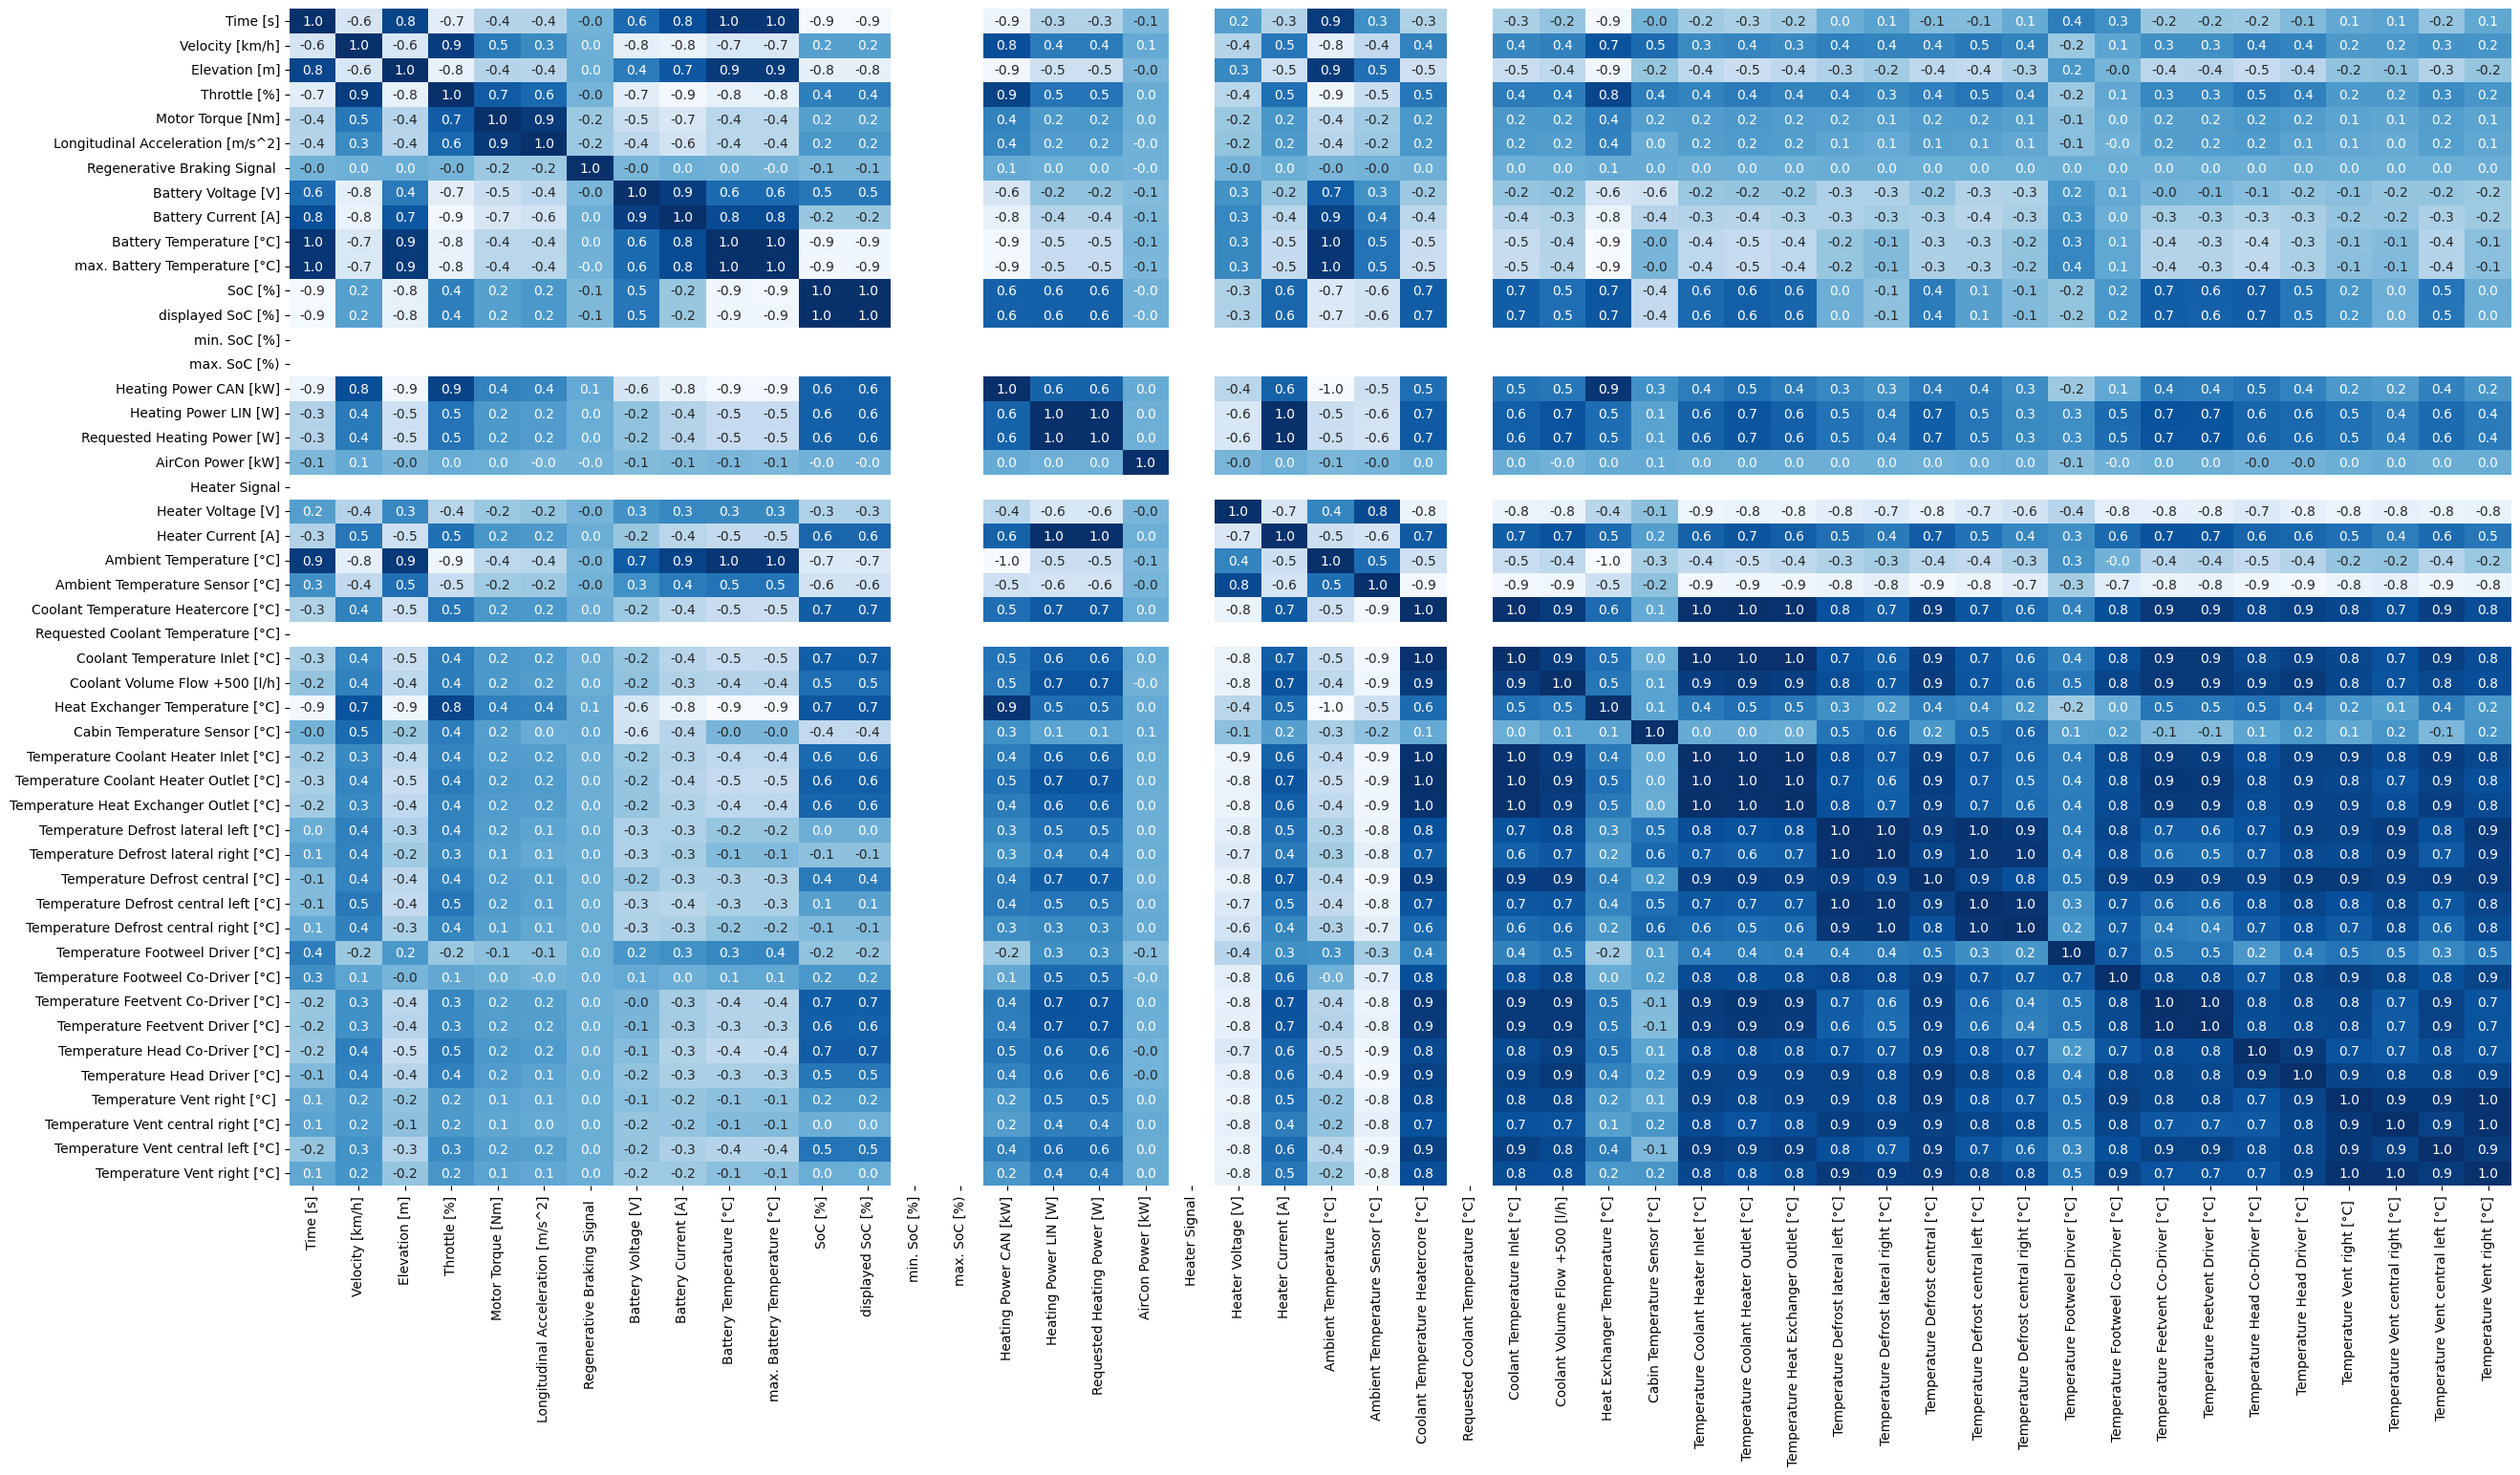

In [ ]:
# Correlation between features
plt.figure(figsize=(30, 16))
seaborn.heatmap(df_trip.corr(),annot=True, cbar=False, cmap='Blues', fmt='.1f')

Setting the color scheme for a plot with negative values.
call this function before plotting any data that contains negative values to ensure a suitable color scheme and style for the plot.

In [ ]:
def set_negative_plot_color():
    plt.figure(figsize=(30, 6), facecolor='black')
    ax = plt.axes()
    ax.set_facecolor("black")
    ax.spines['bottom'].set_color('white')
    ax.spines['top'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.tick_params(colors='white', which='both')
    plt.grid(True)

 x-axis values are taken from the 'Battery Current [A]' column of the df_trip DataFrame, and the y-axis values are taken from the 'Battery Voltage [V]' column. The points on the scatter plot are colored yellow and have a size of 10.


 Battery Behavior Analysis: The scatter plot allows us to observe the relationship between battery current and voltage. It can provide insights into the behavior of the battery, such as how voltage changes with respect to current. This information can be valuable in understanding battery performance, efficiency, and overall health.

 The scatter plot can be used to verify if the battery is behaving as expected based on theoretical models or specifications. By comparing the plot with the expected trends, we can validate the performance and behavior of the battery and identify any deviations that may require further investigation.



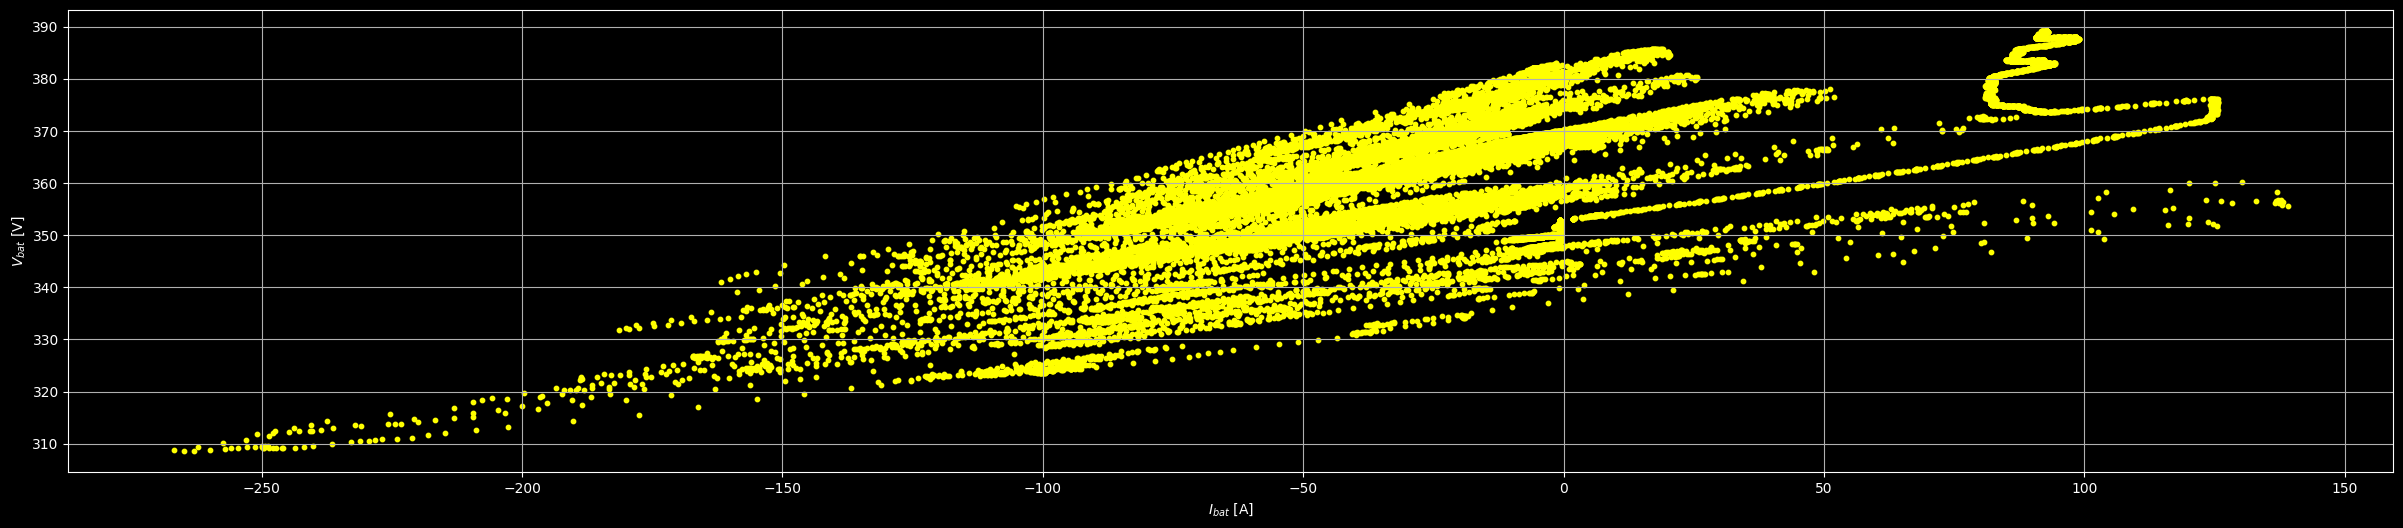

In [ ]:
set_negative_plot_color()
plt.scatter(df_trip['Battery Current [A]'], df_trip['Battery Voltage [V]'], color="yellow", s=10)
plt.xlabel('$I_{bat}$ [A]', color='white')
plt.ylabel('$V_{bat}$ [V]', color='white');

how the voltage varies with different levels of State of Charge. It allows us to analyze the behavior and characteristics of the battery during different charge levels, helping us understand its performance and capacity.






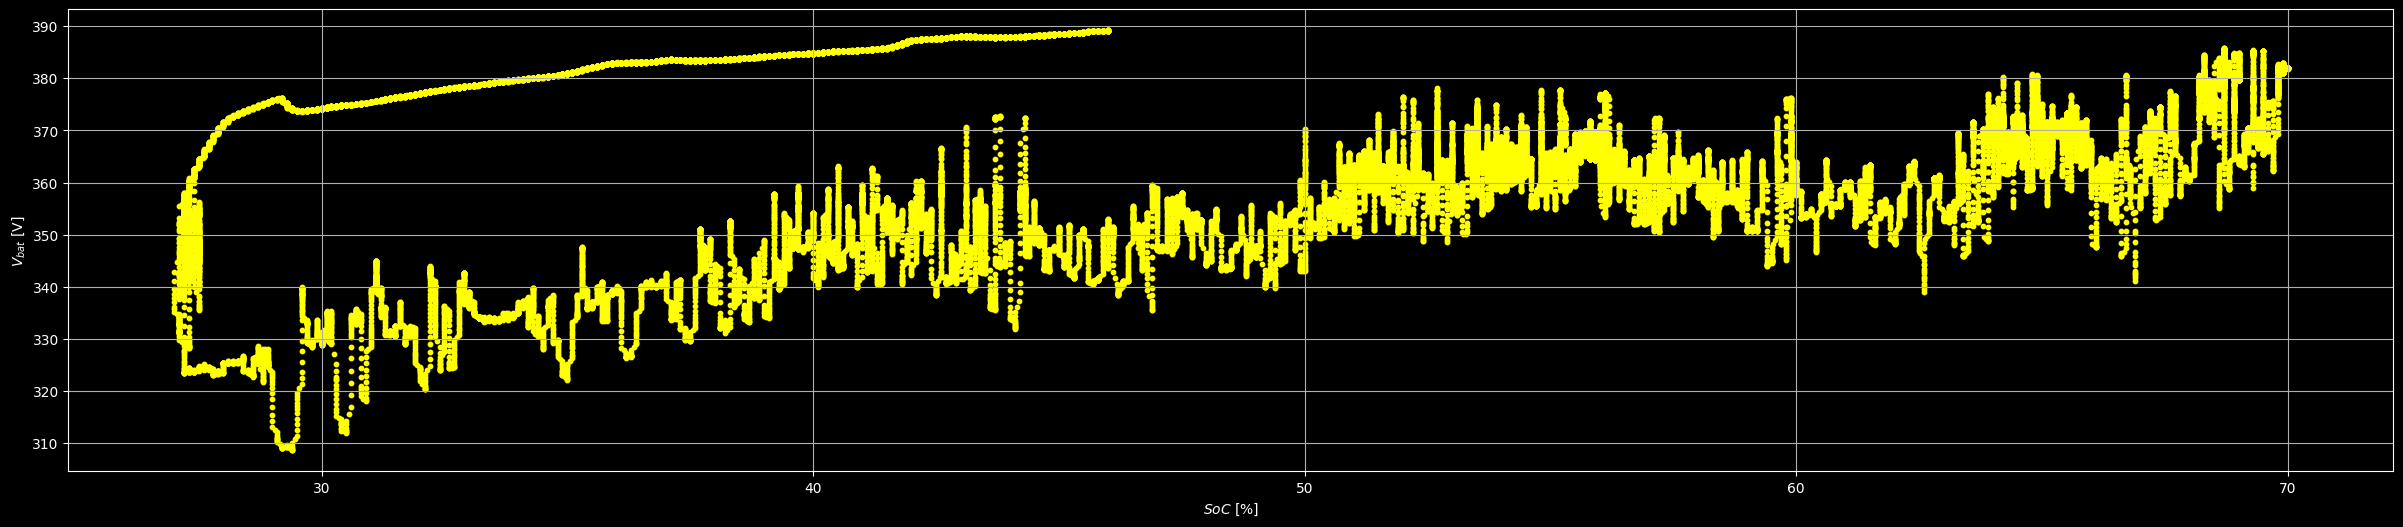

In [ ]:
set_negative_plot_color()
plt.scatter(df_trip['SoC [%]'], df_trip['Battery Voltage [V]'], color="yellow", s=10)
plt.xlabel('$SoC$ [%]', color='white')
plt.ylabel('$V_{bat}$ [V]', color='white');

scatter plot showing the relationship between the battery's State of Charge and the current flowing through it. This plot can provide insights into how the battery current varies with different levels of State of Charge. It allows you to analyze the behavior and characteristics of the battery during different charge levels, helping you understand its performance, efficiency, and overall behavior.

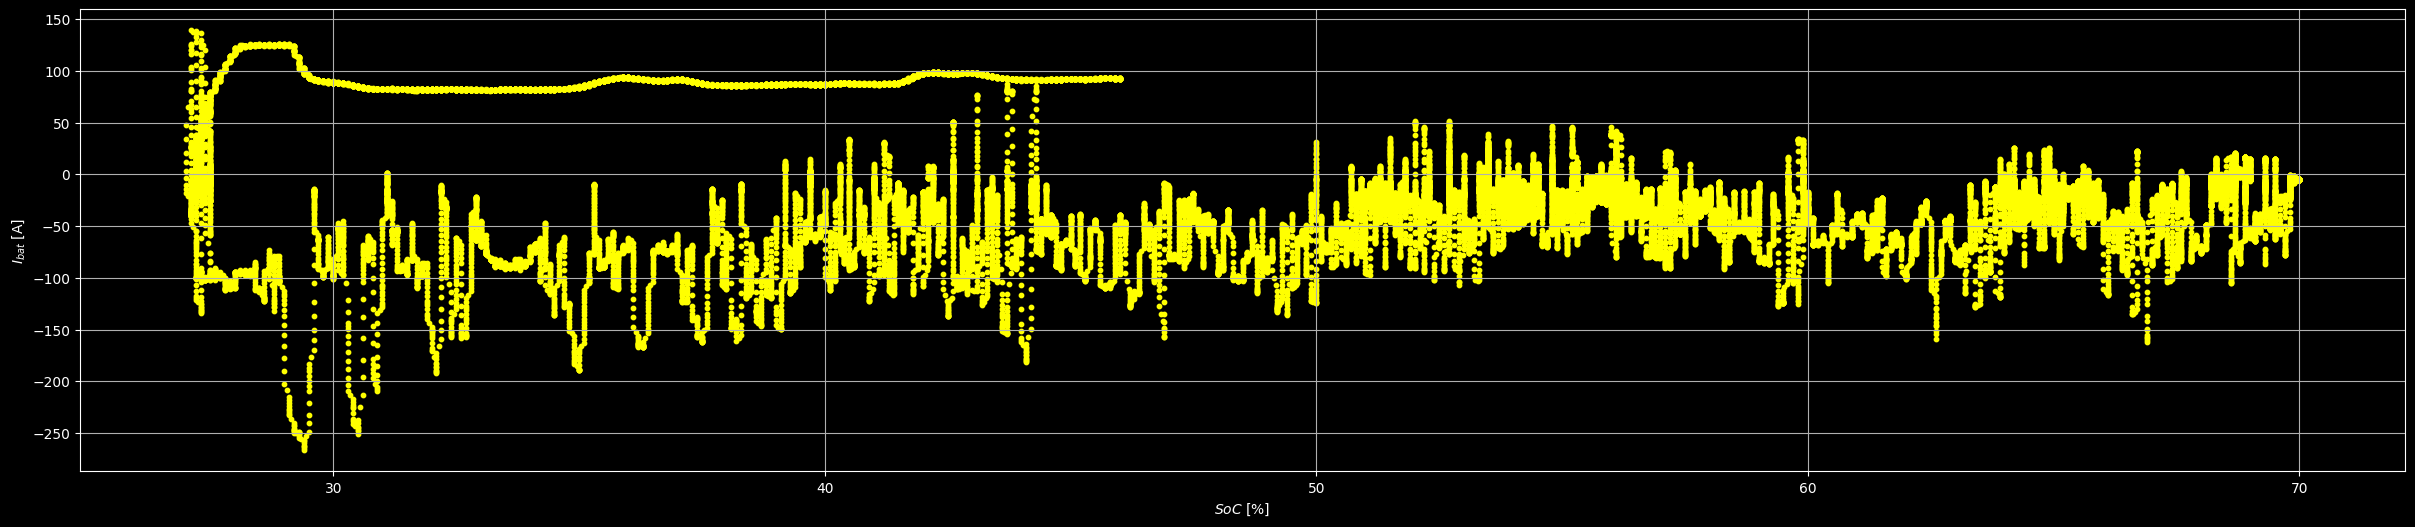

In [ ]:
set_negative_plot_color()
plt.scatter(df_trip['SoC [%]'], df_trip['Battery Current [A]'], color="yellow", s=10)
plt.xlabel('$SoC$ [%]', color='white')
plt.ylabel('$I_{bat}$ [A]', color='white');

scatter plot showing the relationship between the battery's State of Charge and its temperature. This plot can provide insights into how the battery temperature varies with different levels of State of Charge. It allows you to analyze the thermal behavior and characteristics of the battery during different charge levels, helping you understand its performance, heat generation, and thermal management requirements.






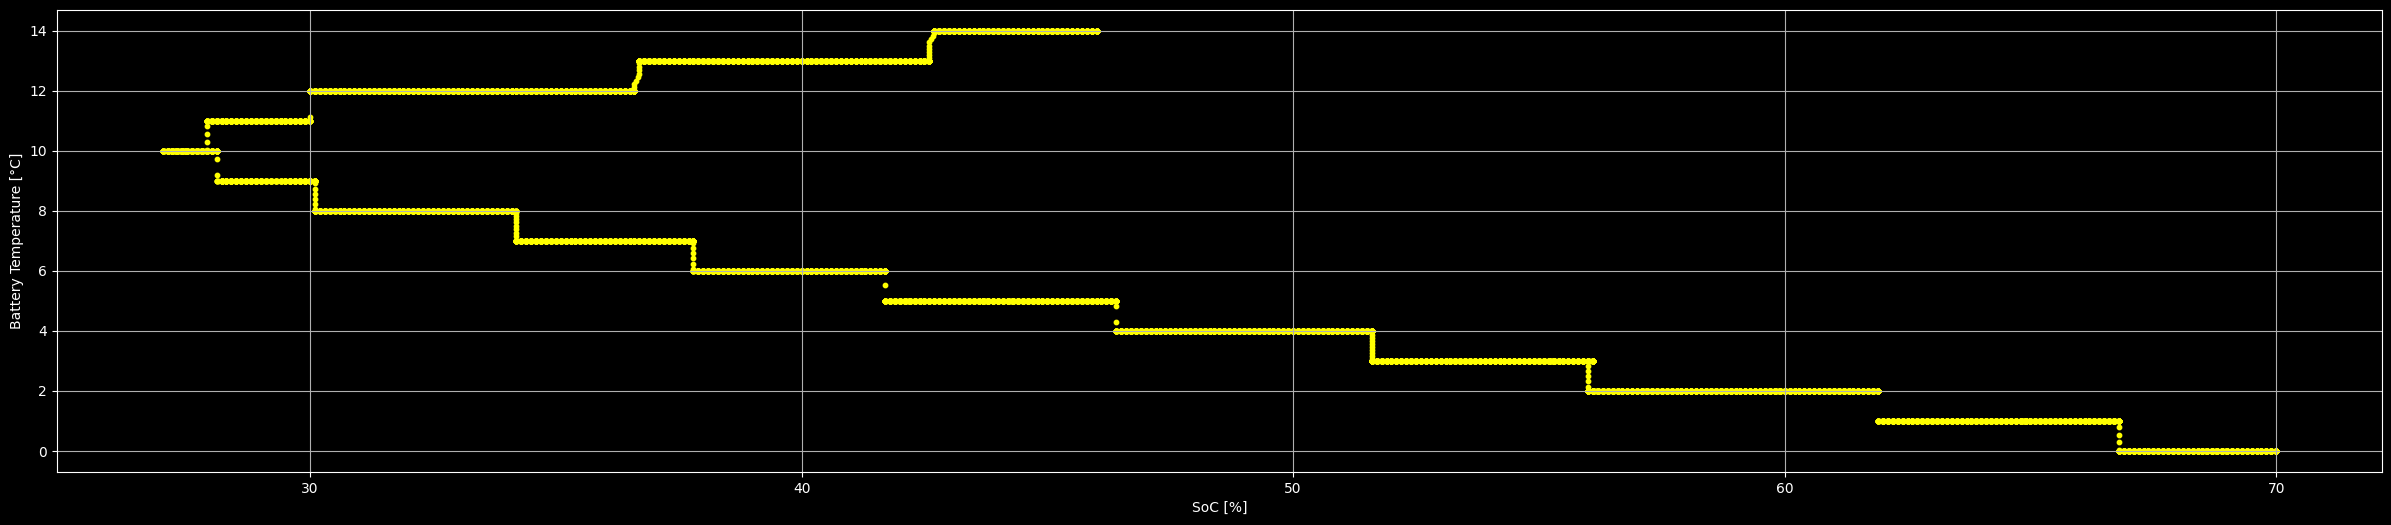

In [ ]:
set_negative_plot_color()
plt.scatter(df_trip['SoC [%]'], df_trip['Battery Temperature [°C]'], color="yellow", s=10)
plt.xlabel('SoC [%]', color='white')
plt.ylabel('Battery Temperature [°C]', color='white');

relationship between motor torque, regenerative braking signal, and their behavior over time. This plot helps in understanding the dynamics of the motor and the impact of regenerative braking on battery current.






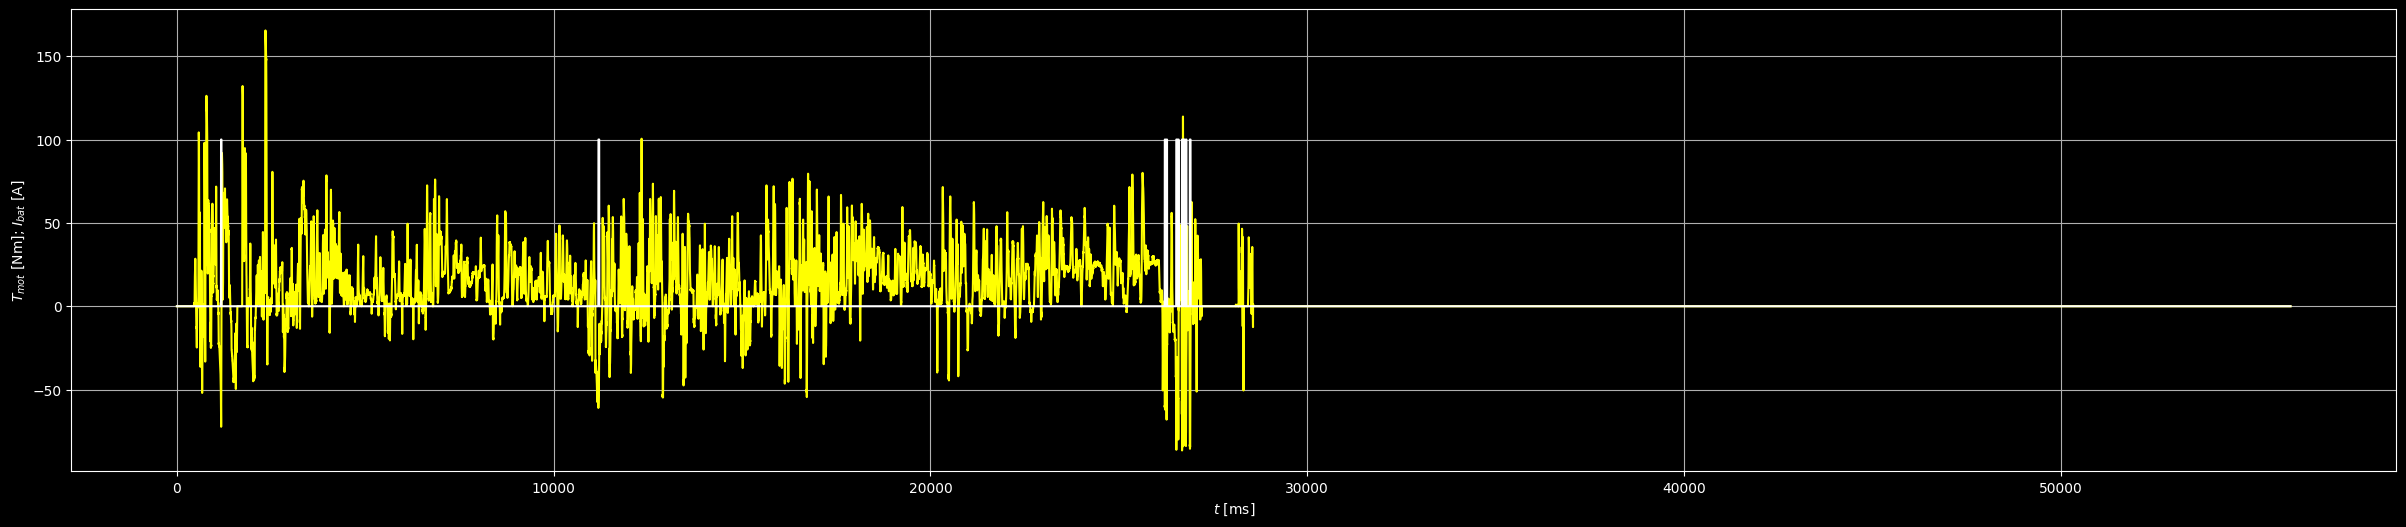

In [ ]:
set_negative_plot_color()
plt.plot(df_trip['Motor Torque [Nm]'], color="yellow")
plt.plot(df_trip['Regenerative Braking Signal ']*100, color="white")
plt.xlabel('$t$ [ms]', color='white')
plt.ylabel('$T_{mot}$ [Nm]; $I_{bat}$ [A]', color='white');

Plot of motor torque, vehicle velocity, and throttle position over time

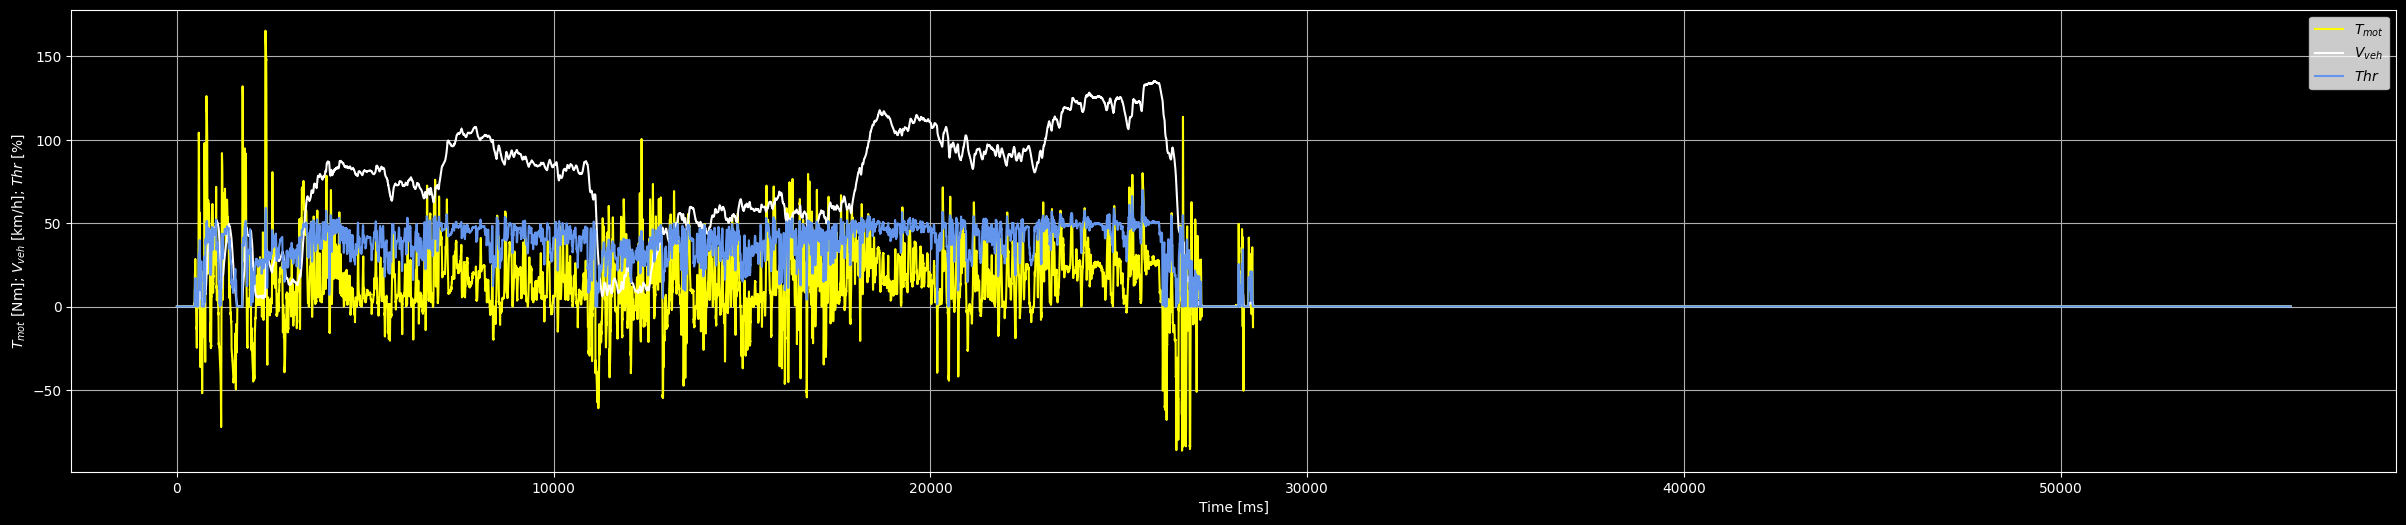

In [ ]:
set_negative_plot_color()
plt.plot(df_trip['Motor Torque [Nm]'], color="yellow")
plt.plot(df_trip['Velocity [km/h]'], color="white")
plt.plot(df_trip['Throttle [%]'], color="cornflowerblue")
plt.xlabel('Time [ms]', color='white')
plt.ylabel('$T_{mot}$ [Nm]; $V_{veh}$ [km/h]; $Thr$ [%]', color='white')
plt.legend(['$T_{mot}$','$V_{veh}$','$Thr$']);

Longitudinal acceleration refers to the rate of change of velocity in the direction of motion. It indicates how the vehicle's speed is changing over time. Positive values indicate acceleration (increasing speed), while negative values indicate deceleration (decreasing speed). By analyzing this line, you can identify the acceleration patterns of the vehicle during the trip.

 line plotted in yellow color represents motor torque. Motor torque refers to the rotational force generated by the vehicle's motor. It represents the amount of twisting force applied by the motor to produce motion. By analyzing this line, you can observe the variations in motor torque throughout the trip, which can provide insights into the power output and performance of the motor.

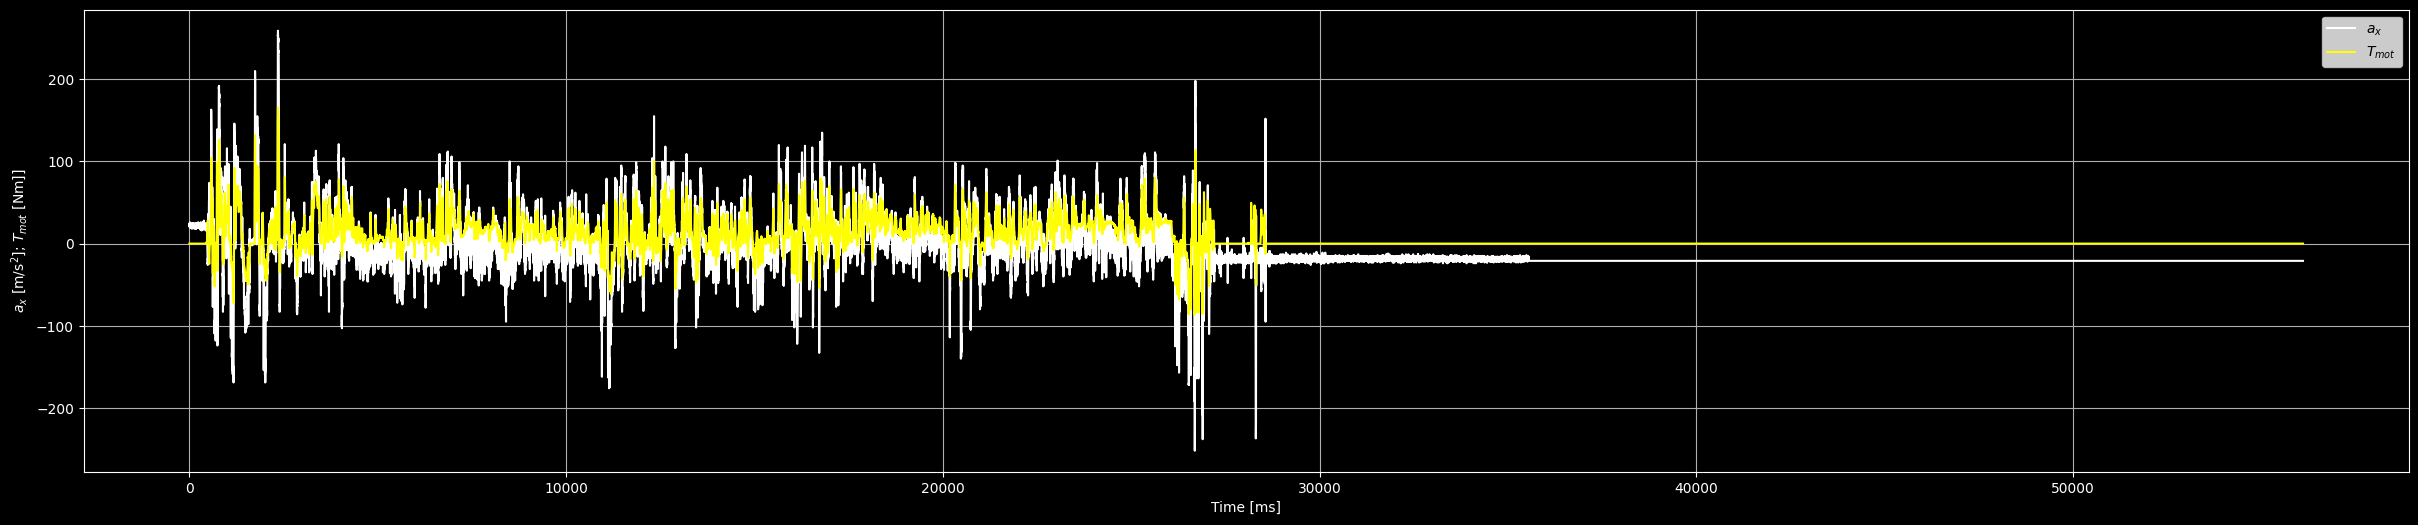

In [ ]:
set_negative_plot_color()
plt.plot(df_trip['Longitudinal Acceleration [m/s^2]']*100, color="white")
plt.plot(df_trip['Motor Torque [Nm]'], color="yellow")
plt.xlabel('Time [ms]', color='white')
plt.ylabel('$a_{x}$ [m/s$^{2}]$; $T_{mot}$ [Nm]]', color='white')
plt.legend(['$a_{x}$','$T_{mot}$']);

This regression_metrics() function is evaluating the performance of a regression model. It calculates three common metrics: Mean Squared Error (average of squared differences between predictions and actual values), Root Mean Squared Error (square root of the Mean Squared Error, easier to interpret since it's in the same unit as the output), and Mean Absolute Error (average of absolute differences between predictions and actuals, less sensitive to outliers)

In [ ]:
#Modelling
def regression_matrics(y_test, y_pred):
    # calculate errors
    mse = mean_squared_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_absolute_error(y_test, y_pred)
    # report error
    print(f'Mean Squared Error: {mse}')
    print(f'Root Mean Square Error: {rmse}')
    print(f'Mean Absolute Error: {mae}')

In [ ]:
def plot_comparison(y_test, y_pred, xlabel, ylabel, dark_mode=False, figsize=(30, 6)):
    if dark_mode:
        plt.figure(figsize=figsize, facecolor='black')
        ax = plt.axes()
        ax.set_facecolor("black")
        ax.spines['bottom'].set_color('gray')
        ax.spines['top'].set_color('gray')
        ax.spines['right'].set_color('gray')
        ax.spines['left'].set_color('gray')
        ax.tick_params(colors='white', which='both')
        plt.plot(y_pred, color="yellow")
        plt.plot(y_test, color="white")
        plt.legend(['Predicted', 'Measured'])
        plt.xlabel(xlabel, color='white')
        plt.ylabel(ylabel, color='white')
    else:
        plt.figure(figsize=figsize)
        plt.plot(y_pred)
        plt.plot(y_test)
        plt.legend(['Predicted', 'Measured'])
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
    plt.grid(True)

In [ ]:
df_x_y = df_master[['Time [s]','Velocity [km/h]','Elevation [m]','Longitudinal Acceleration [m/s^2]','Regenerative Braking Signal ','Battery Voltage [V]',
                    'Battery Current [A]','Battery Temperature [°C]','Heating Power CAN [kW]','AirCon Power [kW]','SoC [%]']].dropna()

plot_dataframe_subplots(df_x_y, nrows=3, ncols=4, figsize=(30, 12))

In [ ]:
# Create and split train and test datasets
X = df_x_y.drop(['Time [s]','SoC [%]'], axis=1)
y = df_x_y[['SoC [%]']]
splitter = int(len(X)*0.7)
X_train = X.values[:splitter]
X_test = X.values[splitter:]
y_train = y.values[:splitter]
y_test = y.values[splitter:]
# Check the dataset sizes
X_train.shape, y_train.shape, X_test.shape, y_test.shape[0]

model being used in this code is a linear regression model
create a linear regression model, train it on the provided data, make predictions using the trained model, and then evaluate and visualize the performance of the model.






Linear Regression:
Mean Squared Error: 7.517178752480486
Root Mean Square Error: 2.7417473903480762
Mean Absolute Error: 2.190320513554083


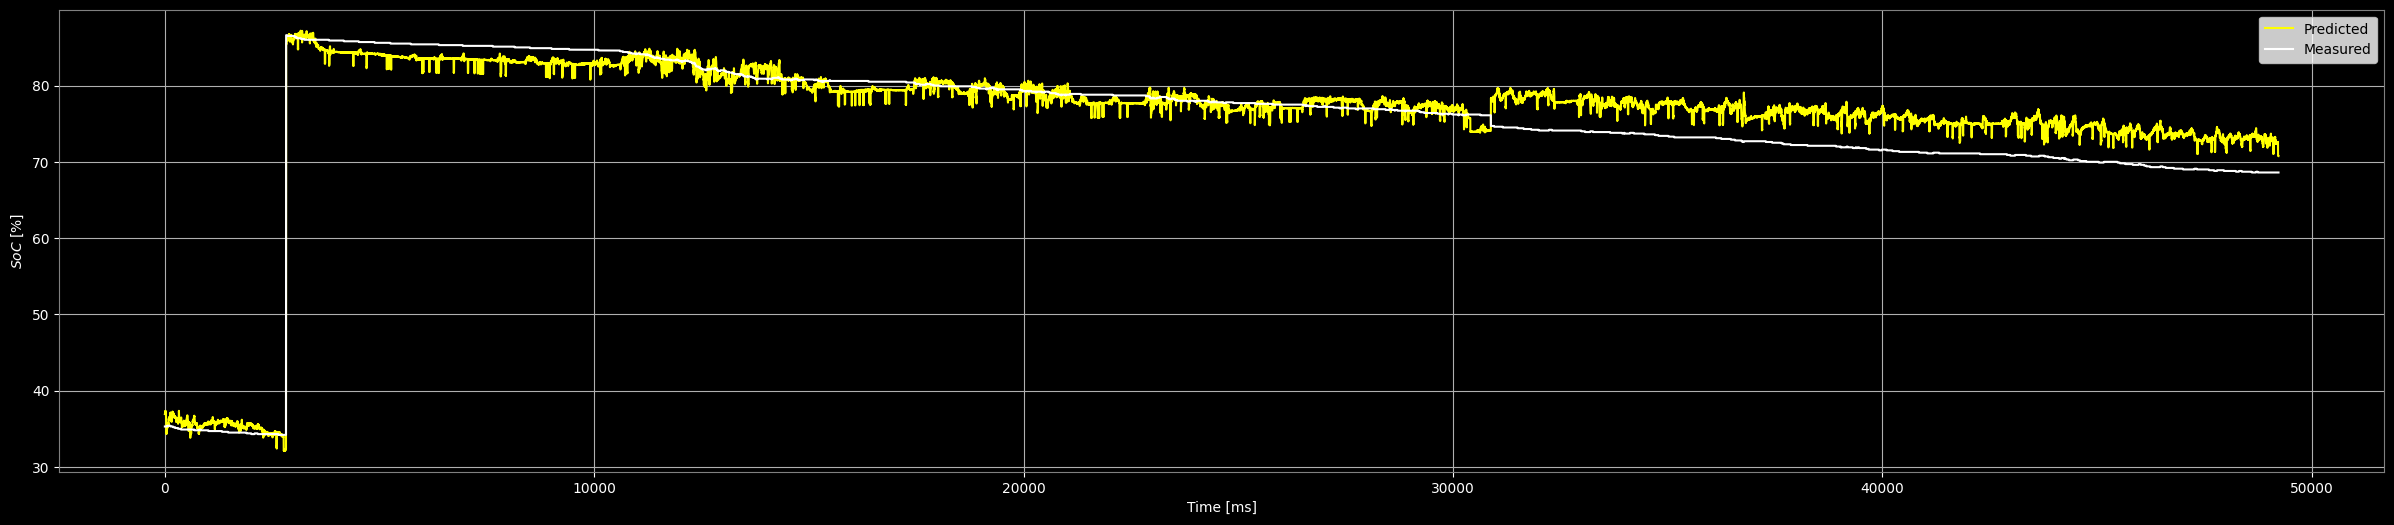

In [ ]:
# 1. Create a model
regressor = LinearRegression()
# 2. Fit the model
regressor.fit(X_train, y_train)
# 3. Make predicitons with the model
y_pred_lr = regressor.predict(X_test)
# 4. Evaluate and visualize
print('Linear Regression:')
regression_matrics(y_test, y_pred_lr)
plot_comparison(y_test=y_test, y_pred=y_pred_lr, xlabel="Time [ms]", ylabel="$SoC$ [%]", dark_mode=True)

neural network model is being created, compiled, fitted to the training data, and then used to make predictions on the test data

1539/1539 [==============================] - 3s 2ms/step
Neural Network:
Mean Squared Error: 142.73159522671884
Root Mean Square Error: 11.947032904730733
Mean Absolute Error: 10.756300813729755


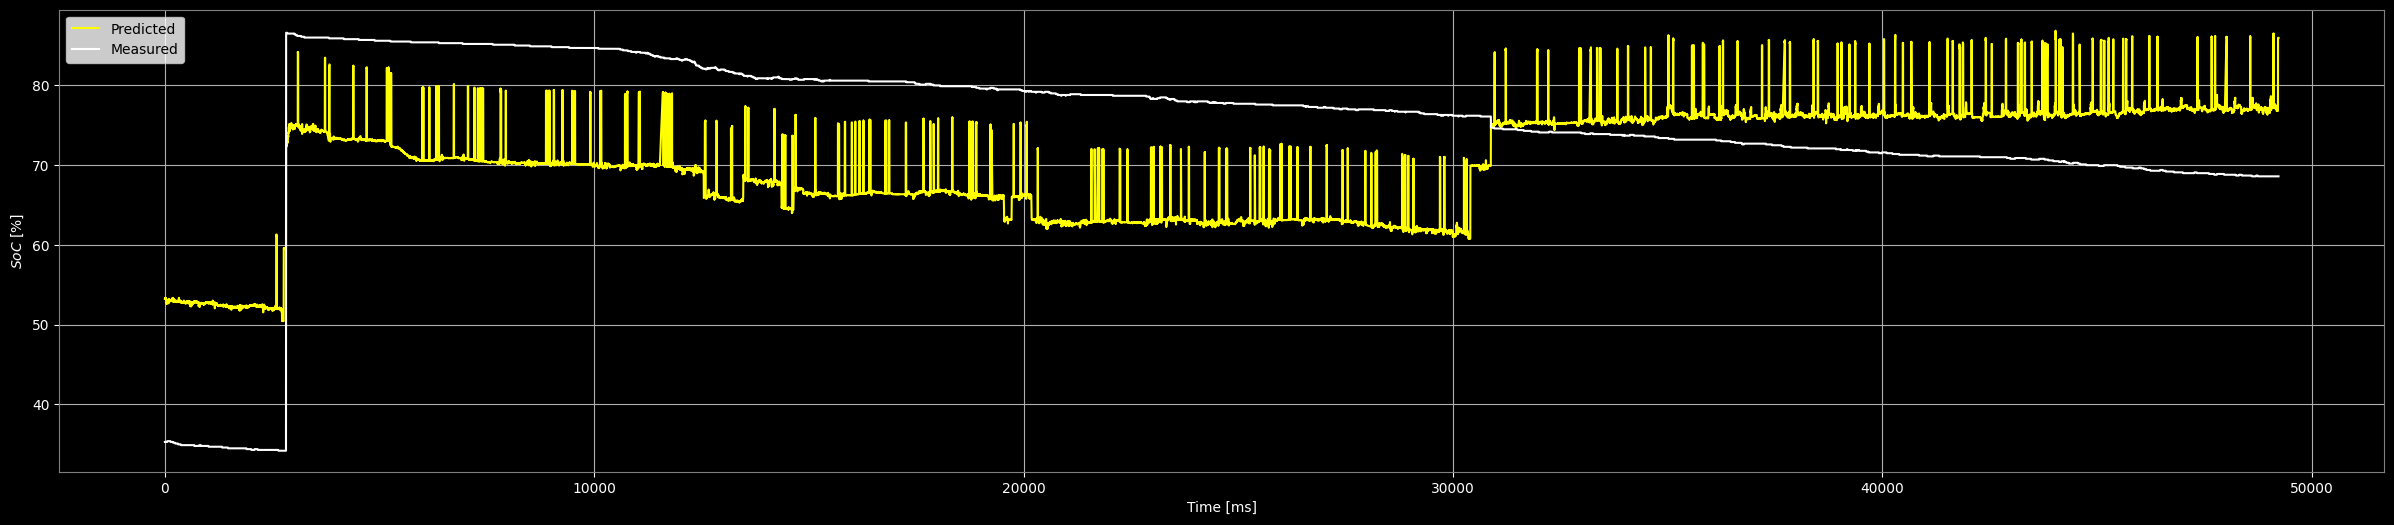

In [ ]:
# 1. Create a model
regressor = Sequential([
    layers.Dense(10),
    layers.Dense(1),
])
# 2. Compile a model
regressor.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss=losses.mae,
                  metrics=["mae"])
# 3. Fit a model
regressor.fit(X_train, y_train, epochs=5, verbose=0)
# 4. Validate the model
y_pred_nn = regressor.predict(X_test)
# 5. Evaluate and visualize
print('Neural Network:')
regression_matrics(y_test, y_pred_nn)
plot_comparison(y_test=y_test, y_pred=y_pred_nn, xlabel="Time [ms]", ylabel="$SoC$ [%]", dark_mode=True)

1539/1539 [==============================] - 2s 1ms/step
Neural Network:
Mean Squared Error: 118.45899086762823
Root Mean Square Error: 10.883886753712032
Mean Absolute Error: 10.11346560975206


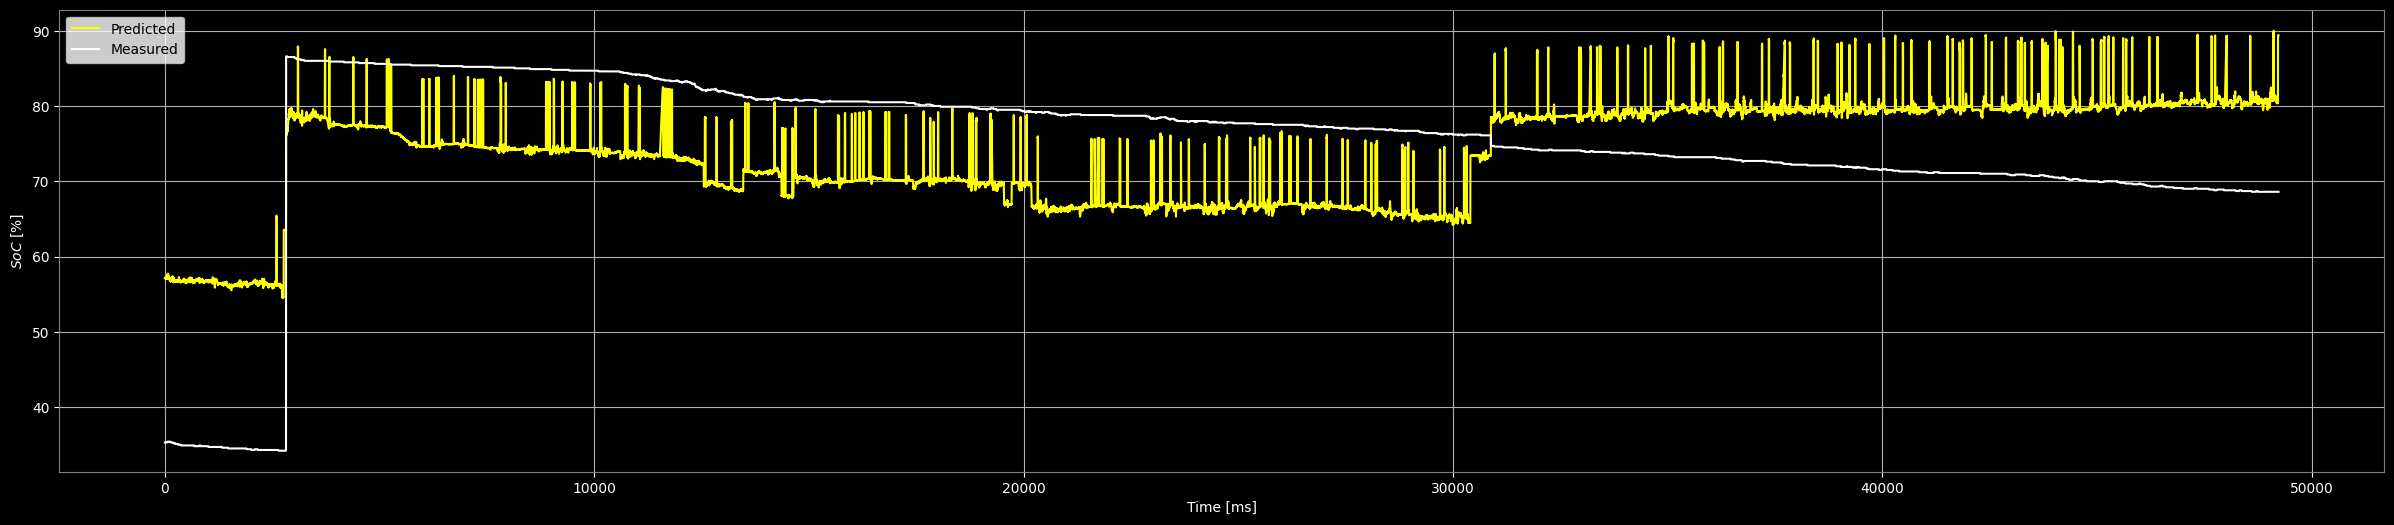

In [ ]:
# 1. Create a model
regressor = Sequential([
    layers.Dense(100),
    layers.Dense(1),
])
# 2. Compile a model
regressor.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss=losses.mae,
                  metrics=["mae"])
# 3. Fit a model
regressor.fit(X_train, y_train, epochs=5, verbose=0)
# 4. Validate the model
y_pred_nn = regressor.predict(X_test)
# 5. Evaluate and visualize
print('Neural Network:')
regression_matrics(y_test, y_pred_nn)
plot_comparison(y_test=y_test, y_pred=y_pred_nn, xlabel="Time [ms]", ylabel="$SoC$ [%]", dark_mode=True)

1539/1539 [==============================] - 2s 1ms/step
Neural Network:
Mean Squared Error: 132.6732601670933
Root Mean Square Error: 11.518387915289765
Mean Absolute Error: 10.563491302716521


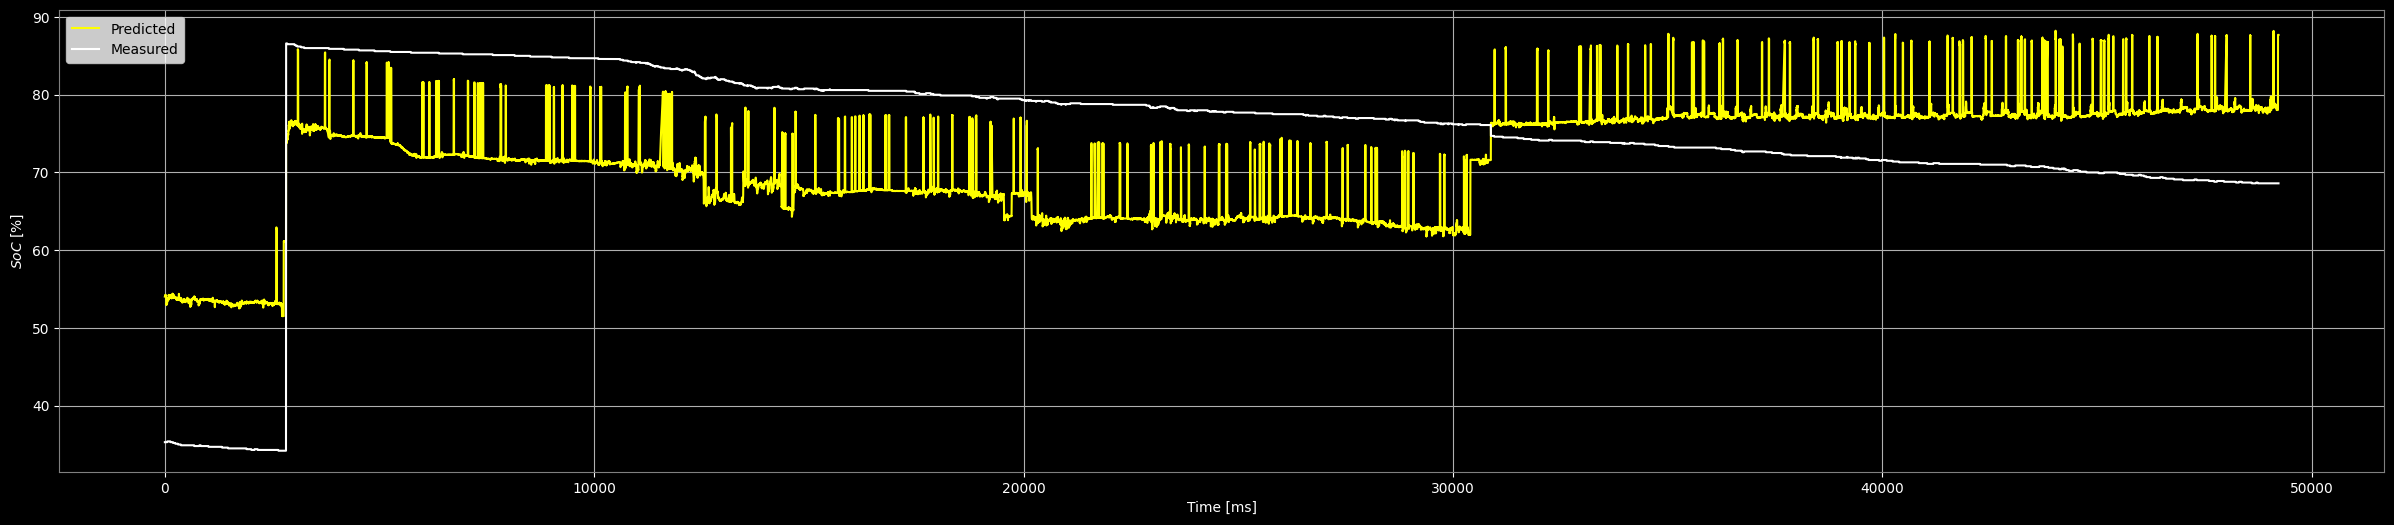

In [ ]:
# 1. Create a model
regressor = Sequential([
    layers.Dense(10),
    layers.Dense(10),
    layers.Dense(1),
])
# 2. Compile a model
regressor.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss=losses.mae,
                  metrics=["mae"])
# 3. Fit a model
regressor.fit(X_train, y_train, epochs=10, verbose=0)
# 4. Validate the model
y_pred_nn = regressor.predict(X_test)
# 5. Evaluate and visualize
print('Neural Network:')
regression_matrics(y_test, y_pred_nn)
plot_comparison(y_test=y_test, y_pred=y_pred_nn, xlabel="Time [ms]", ylabel="$SoC$ [%]", dark_mode=True)

1539/1539 [==============================] - 2s 1ms/step
Neural Network:
Mean Squared Error: 115.9572041770428
Root Mean Square Error: 10.768342684788722
Mean Absolute Error: 10.017386613722413


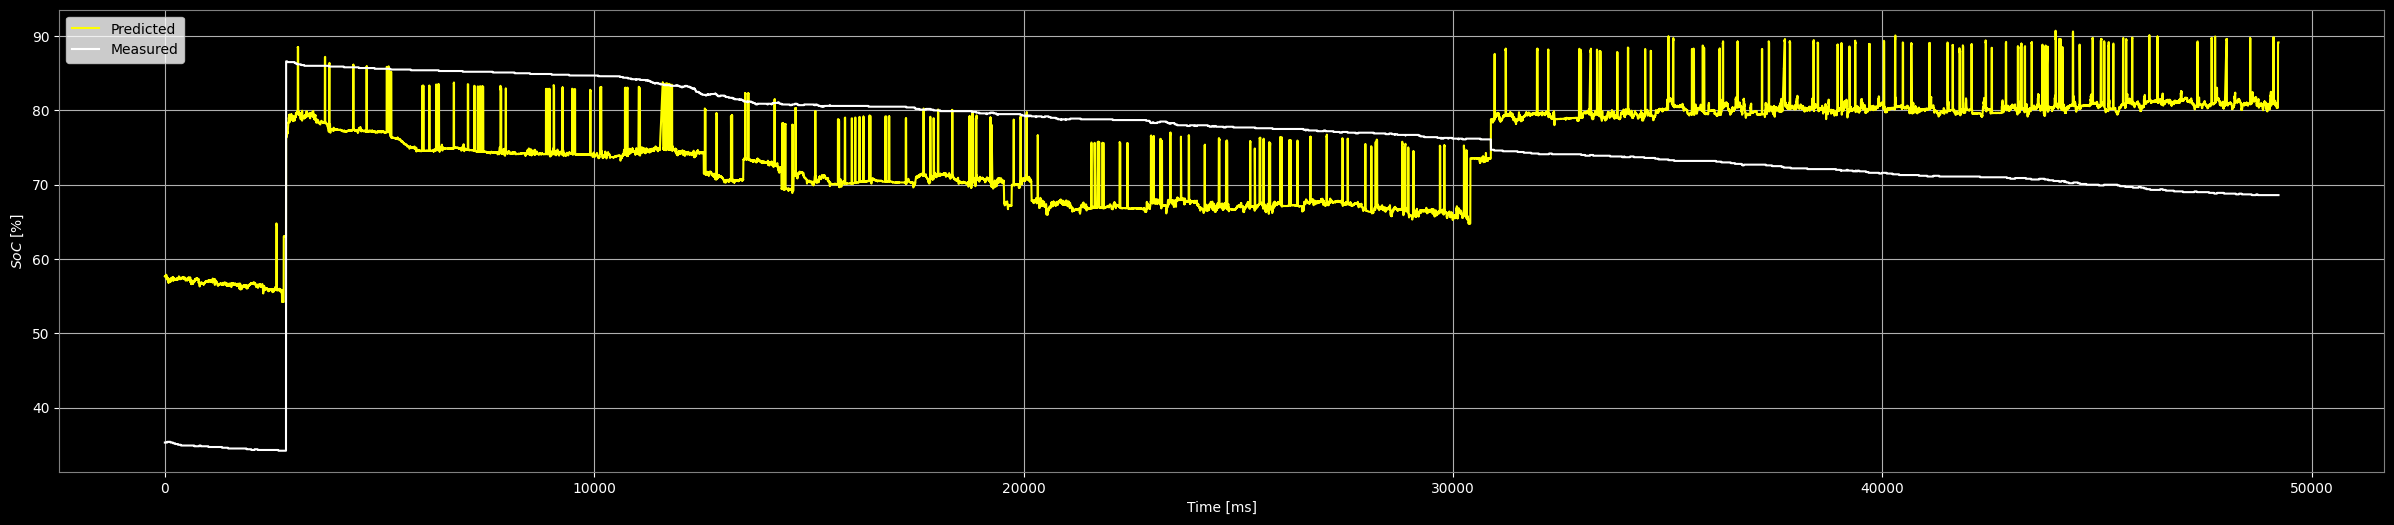

In [ ]:
# 1. Create a model
regressor = Sequential([
    layers.Dense(10),
    layers.Dense(100),
    layers.Dense(1),
])
# 2. Compile a model
regressor.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss=losses.mae,
                  metrics=["mae"])
# 3. Fit a model
regressor.fit(X_train, y_train, epochs=10, verbose=0)
# 4. Validate the model
y_pred_nn = regressor.predict(X_test)
# 5. Evaluate and visualize
print('Neural Network:')
regression_matrics(y_test, y_pred_nn)
plot_comparison(y_test=y_test, y_pred=y_pred_nn, xlabel="Time [ms]", ylabel="$SoC$ [%]", dark_mode=True)

1539/1539 [==============================] - 2s 1ms/step
Neural Network:
Mean Squared Error: 128.16559870840726
Root Mean Square Error: 11.32102463156084
Mean Absolute Error: 10.429846458091756


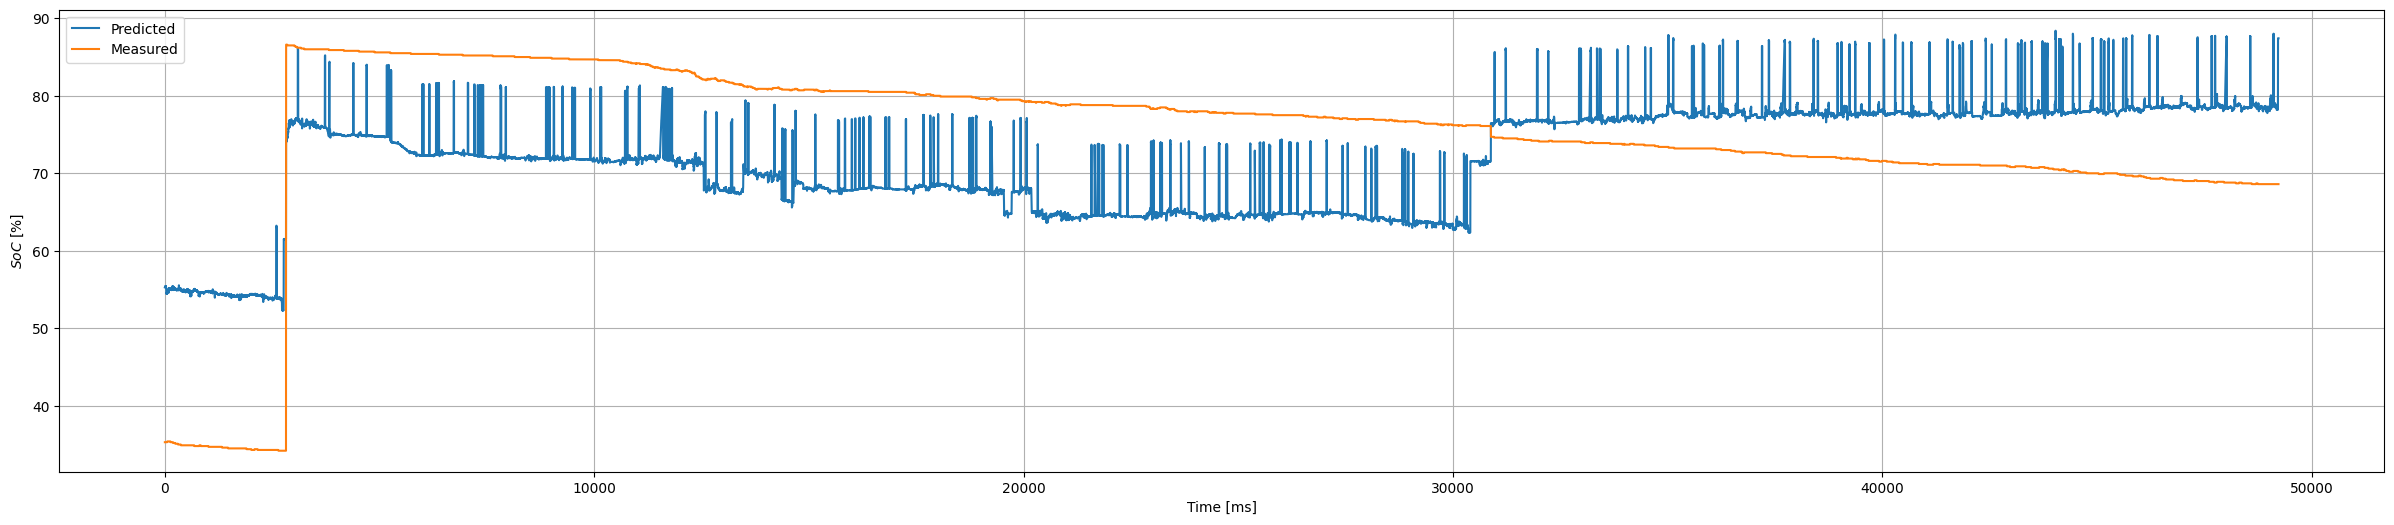

In [ ]:
# 1. Create a model
regressor = Sequential([
    layers.Dense(10),
    layers.Dense(100),
    layers.Dense(100),
    layers.Dense(1),
])
# 2. Compile a model
regressor.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
                  loss=losses.mae,
                  metrics=["mae"])
# 3. Fit a model
regressor.fit(X_train, y_train, epochs=20, verbose=0)
# 4. Validate the model
y_pred_nn = regressor.predict(X_test)
# 5. Evaluate and visualize
print('Neural Network:')
regression_matrics(y_test, y_pred_nn)
plot_comparison(y_test=y_test, y_pred=y_pred_nn, xlabel="Time [ms]", ylabel="$SoC$ [%]", dark_mode=False)

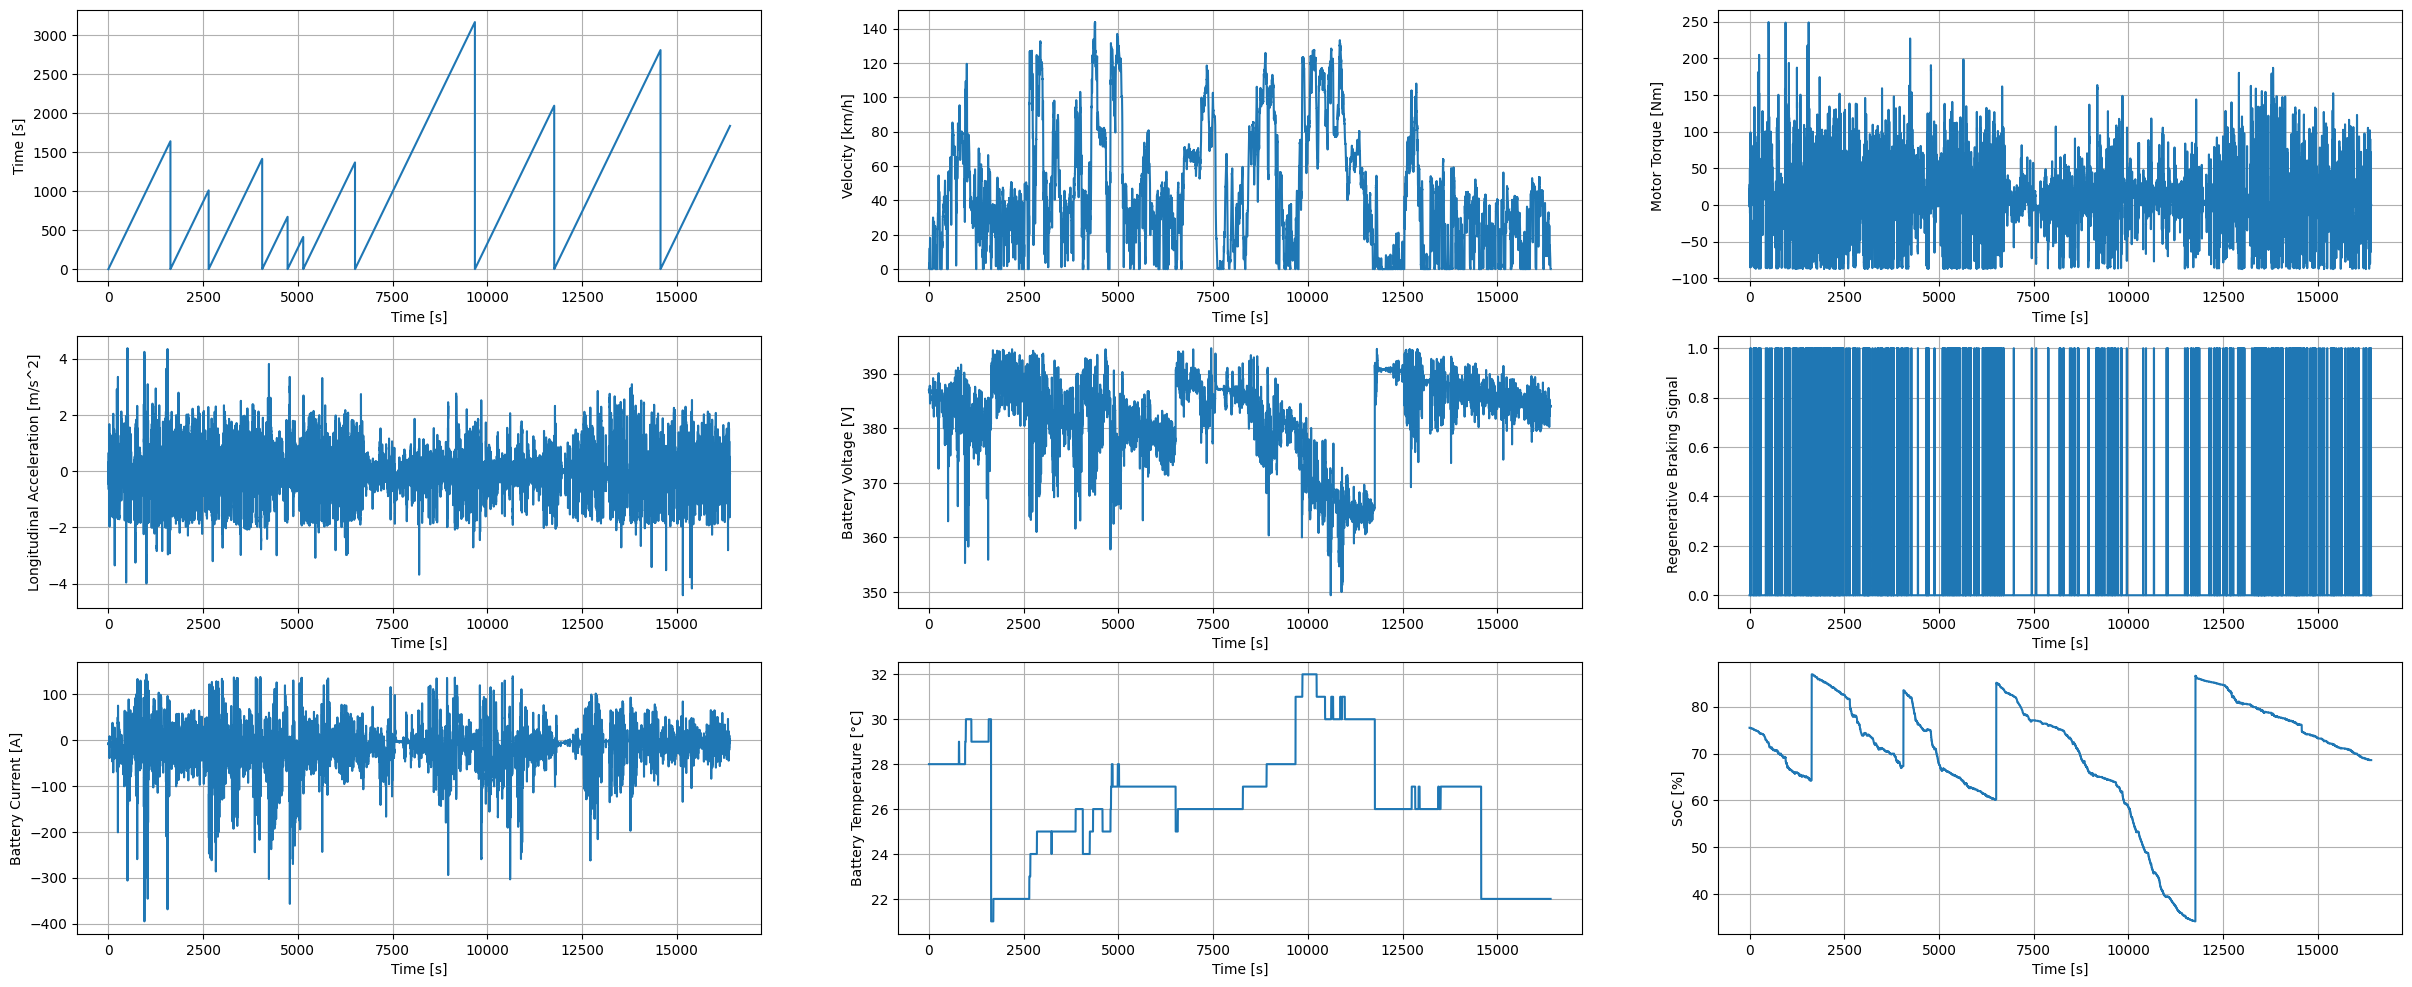

In [ ]:
df_x_y = df_master[['Time [s]','Velocity [km/h]','Motor Torque [Nm]','Longitudinal Acceleration [m/s^2]','Battery Voltage [V]','Regenerative Braking Signal ',
                    'Battery Current [A]','Battery Temperature [°C]','SoC [%]']].dropna()

plot_dataframe_subplots(df_x_y, nrows=3, ncols=3, figsize=(30, 12))

In [ ]:
# Create and split train and test datasets
X = df_x_y.drop(['Time [s]','SoC [%]'], axis=1)
y = df_x_y[['SoC [%]']]
splitter = int(len(X)*0.7)
X_train = X.values[:splitter]
X_test = X.values[splitter:]
y_train = y.values[:splitter]
y_test = y.values[splitter:]
# Check the dataset sizes
X_train.shape[0] == y_train.shape[0], X_test.shape[0] == y_test.shape[0],\
    X_train.shape[1] == X_test.shape[1], y_train.shape[1] == y_test.shape[1]


(True, True, True, True)

Linear Regression:
Mean Squared Error: 8.904426730927666
Root Mean Square Error: 2.984028607592036
Mean Absolute Error: 2.5425395796217733


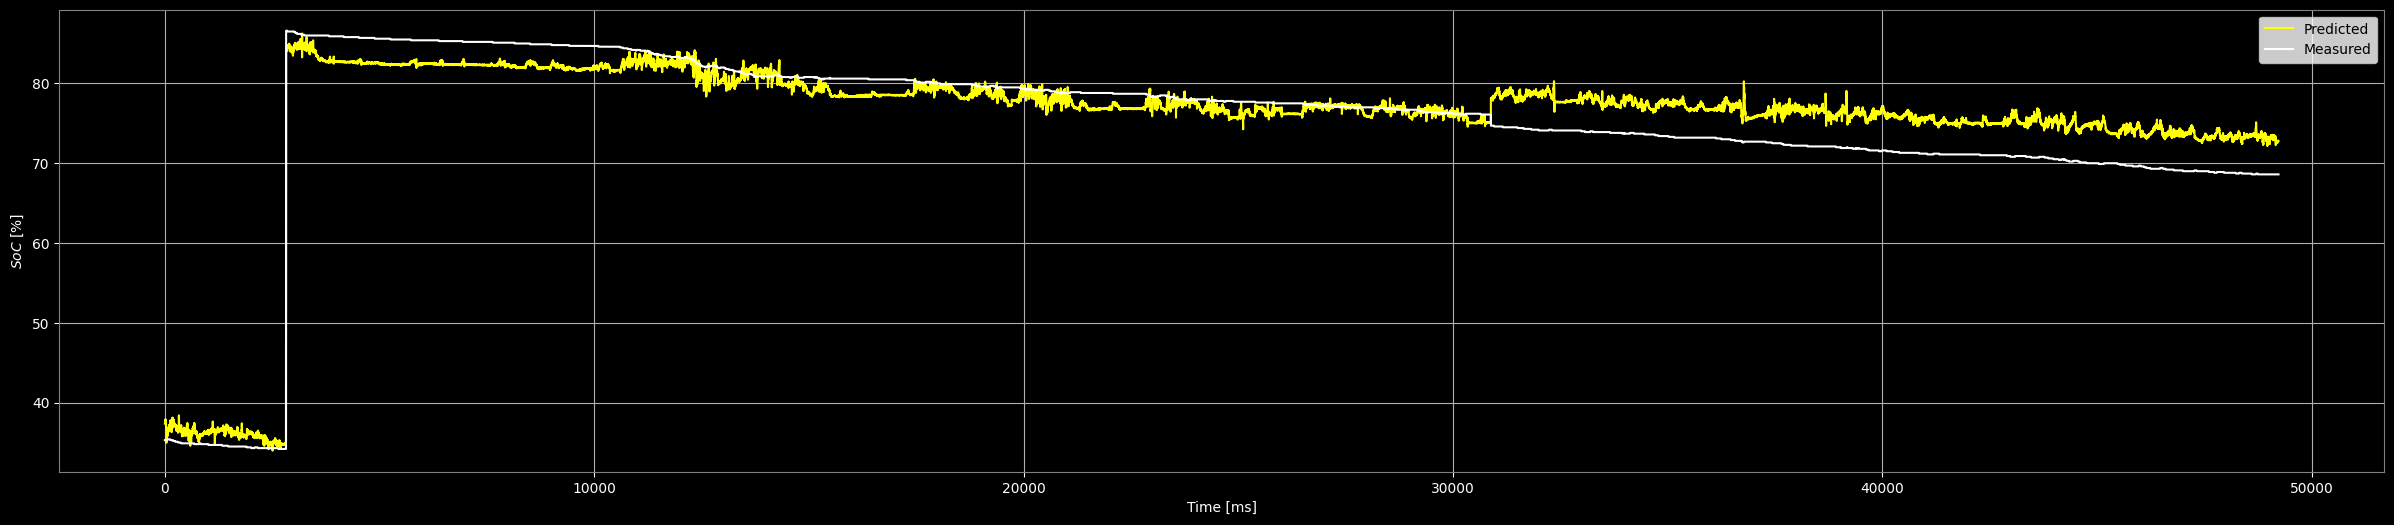

In [ ]:
# 1. Create a model
regressor = LinearRegression()
# 2. Fit the model
regressor.fit(X_train, y_train)
# 3. Make predicitons with the model
y_pred_lr = regressor.predict(X_test)
# 4. Evaluate and visualize
print('Linear Regression:')
regression_matrics(y_test, y_pred_lr)
plot_comparison(y_test=y_test, y_pred=y_pred_lr, xlabel="Time [ms]", ylabel="$SoC$ [%]", dark_mode=True)

In [ ]:
#battery temp. prediction
X = df_x_y.drop(['Battery Temperature [°C]'], axis=1)
y = df_x_y[['Battery Temperature [°C]']]

splitter = int(len(X)*0.7)
X_train = X.values[:splitter]
X_test = X.values[splitter:]
y_train = y.values[:splitter]
y_test = y.values[splitter:]
# Check the dataset sizes
X_train.shape[0] == y_train.shape[0], X_test.shape[0] == y_test.shape[0],\
    X_train.shape[1] == X_test.shape[1], y_train.shape[1] == y_test.shape[1]


(True, True, True, True)

Linear Regression:
Mean Squared Error: 11.678373219232702
Root Mean Square Error: 3.4173634894802603
Mean Absolute Error: 3.086816072415663


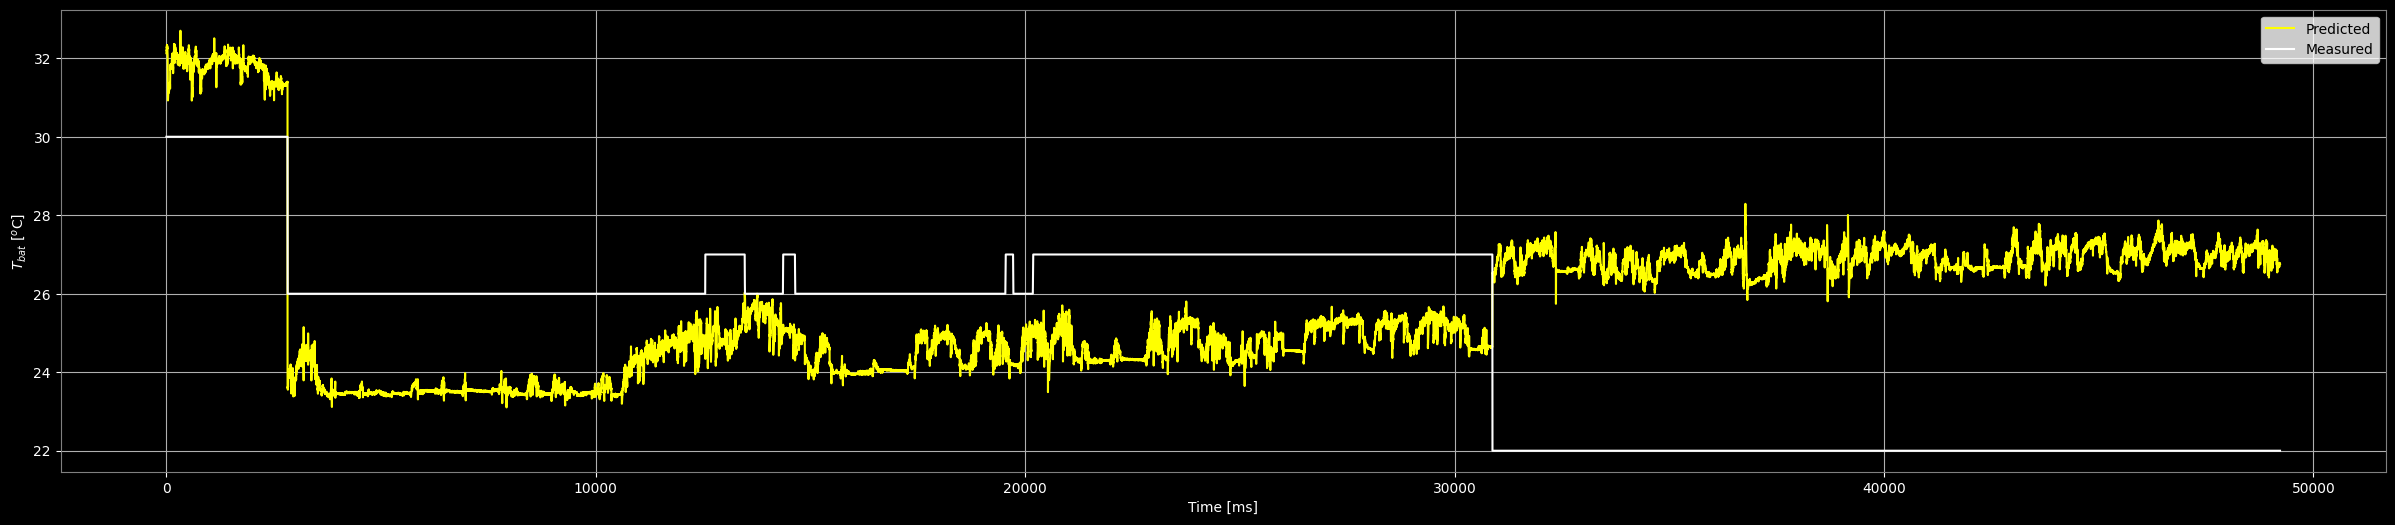

In [ ]:
# 1. Create a model
regressor = LinearRegression()
# 2. Fit the model
regressor.fit(X_train, y_train)
# 3. Make predicitons with the model
y_pred_lr = regressor.predict(X_test)
# 4. Evaluate and visualize
print('Linear Regression:')
regression_matrics(y_test, y_pred_lr)
plot_comparison(y_test=y_test, y_pred=y_pred_lr, xlabel="Time [ms]", ylabel='$T_{bat}$ [$^o$C]', dark_mode=True)

In [ ]:
# Create and split train and test datasets
X = df_x_y.drop(['Time [s]','Battery Temperature [°C]'], axis=1)
y = df_x_y[['Battery Temperature [°C]']]
splitter = int(len(X)*0.7)
X_train = X.values[:splitter]
X_test = X.values[splitter:]
y_train = y.values[:splitter]
y_test = y.values[splitter:]
# Check the dataset sizes
X_train.shape, y_train.shape, X_test.shape, y_test.shape[0]

((114857, 9), (114857, 1), (49225, 9), 49225)

1539/1539 [==============================] - 2s 1ms/step
Neural Network:
Mean Squared Error: 8.137644471685777
Root Mean Square Error: 2.852655687545515
Mean Absolute Error: 2.7742108584146803


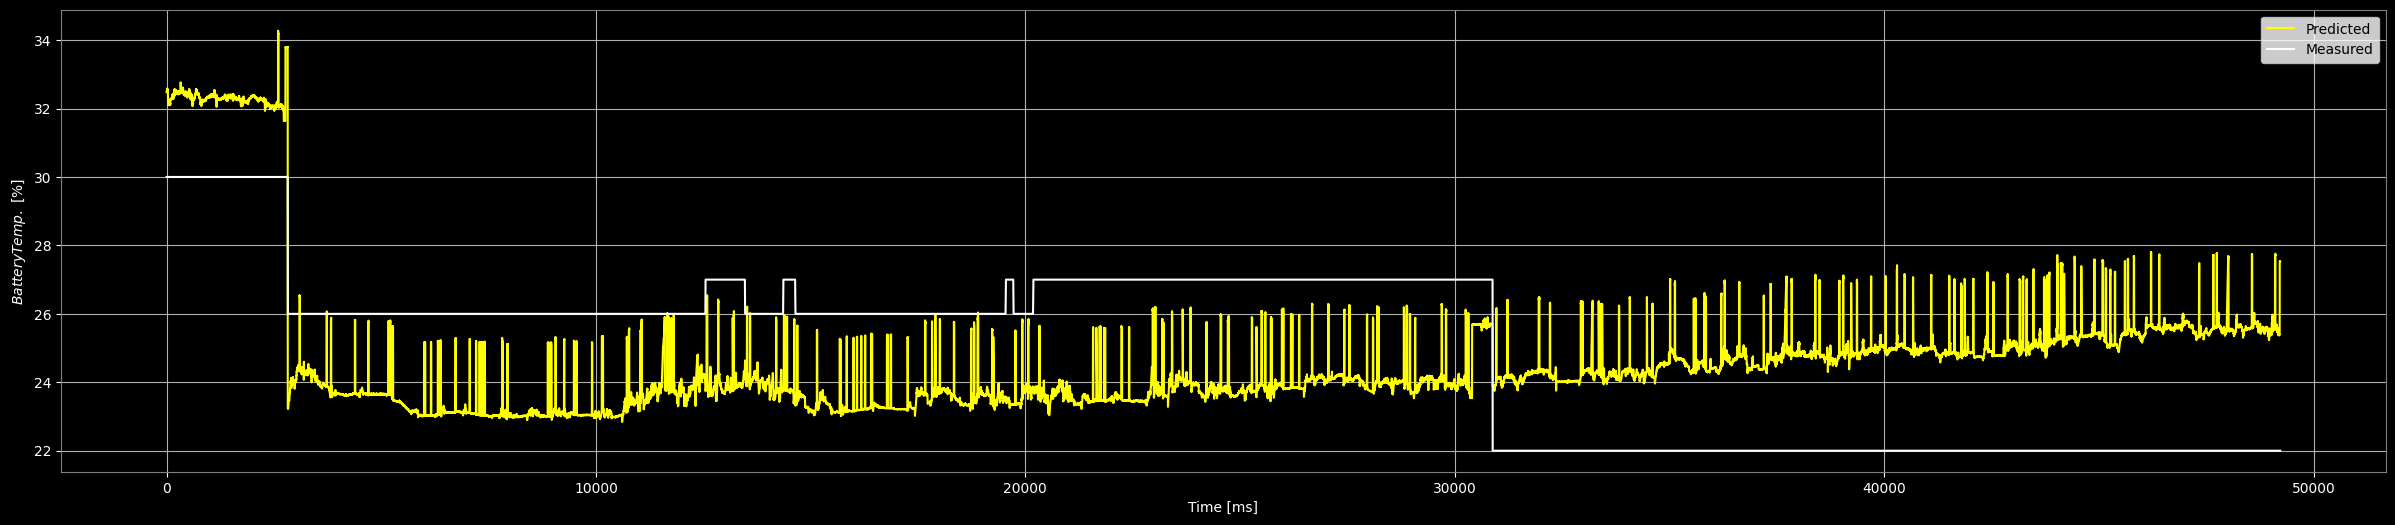

In [ ]:
# 1. Create a model
regressor = Sequential([
    layers.Dense(10),
    layers.Dense(100),
    layers.Dense(1),
])
# 2. Compile a model
regressor.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss=losses.mae,
                  metrics=["mae"])
# 3. Fit a model
regressor.fit(X_train, y_train, epochs=10, verbose=0)
# 4. Validate the model
y_pred_nn = regressor.predict(X_test)
# 5. Evaluate and visualize
print('Neural Network:')
regression_matrics(y_test, y_pred_nn)
plot_comparison(y_test=y_test, y_pred=y_pred_nn, xlabel="Time [ms]", ylabel="$Battery Temp.$ [%]", dark_mode=True)

1539/1539 [==============================] - 2s 1ms/step
Neural Network:
Mean Squared Error: 8.09456120755887
Root Mean Square Error: 2.845094235268644
Mean Absolute Error: 2.761096300068357


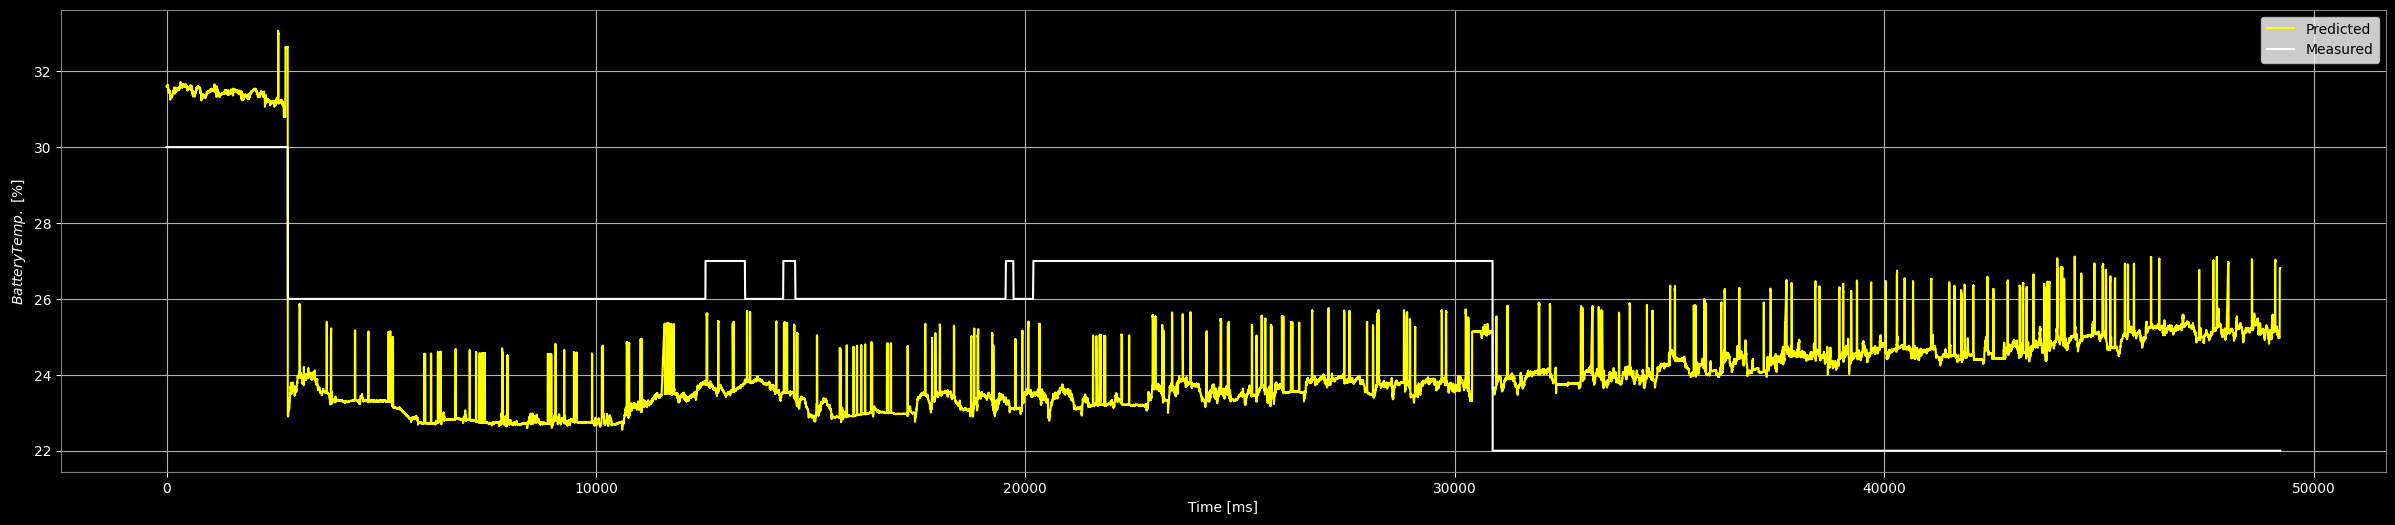

In [ ]:
# 1. Create a model
regressor = Sequential([
    layers.Dense(10),
    layers.Dense(100),
    layers.Dense(100),
    layers.Dense(1),
])
# 2. Compile a model
regressor.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss=losses.mae,
                  metrics=["mae"])
# 3. Fit a model
regressor.fit(X_train, y_train, epochs=10, verbose=0)
# 4. Validate the model
y_pred_nn = regressor.predict(X_test)
# 5. Evaluate and visualize
print('Neural Network:')
regression_matrics(y_test, y_pred_nn)
plot_comparison(y_test=y_test, y_pred=y_pred_nn, xlabel="Time [ms]", ylabel="$Battery Temp.$ [%]", dark_mode=True)